# Projeto de SCD — cadeia completa em banda base

Neste notebook eu organizei uma simulação completa de comunicação digital. A ideia é começar com uma mensagem de texto, transformar essa mensagem em bits, fazer o mapeamento em símbolos, aplicar a formatação de pulso e depois transmitir o sinal por um canal com ruído, atraso e distorção.

No receptor, o sinal não é recuperado direto. Primeiro é feita a sincronização usando um preâmbulo conhecido, depois vem a equalização, o filtro casado, a amostragem, o demapping e, por fim, a reconstrução do texto.

Além dos resultados numéricos, deixei os gráficos principais para acompanhar o que acontece em cada etapa: sinal no tempo, espectro, constelações, trajetória I/Q, diagrama de olho e BER em função da SNR.

## Ideia principal do projeto

O ponto mais importante desta versão é que o receptor não usa a mensagem completa como referência. Ele conhece apenas o preâmbulo colocado no início do quadro e usa esse trecho para encontrar o atraso por correlação.

Depois que o início do sinal é encontrado, o receptor faz o restante do processamento: equalização, filtro casado, escolha do melhor instante de amostragem, demapping, deshuffling e recuperação do texto.

Assim, a mensagem final é recuperada depois de passar pelo canal, e não a partir de um sinal limpo antes da transmissão.

## 1. Configuração geral

Aqui ficam os principais parâmetros da simulação. A ideia é mudar somente esta parte quando for testar outra modulação, outro pulso, outro valor de SNR ou outro atraso.

Modulações disponíveis: `polar`, `ook`, `4pam`, `8pam`, `4qam` e `16qam`.

Pulsos disponíveis: `nrz`, `rz` e `rrc`.

In [1]:
# =========================================================
# CONFIGURAÇÃO ÚNICA DO SISTEMA
# =========================================================

texto = (
   "Neste projeto, a mensagem de texto não é simplesmente copiada para o receptor. Nós simulamos o envio real: o texto é convertido em bits, passa por um canal com ruído e atraso, e o nosso receptor faz todo o trabalho de sincronizar e equalizar o sinal degradado para recuperar a mensagem original de forma autêntica."
)

# Modulação principal da simulação
Mod_format = '16qam'
M = 16

# Pulse shaping
Pulse_shape = 'rrc'       # 'nrz', 'rz' ou 'rrc'
K1 = 8                    # amostras por símbolo no pulse shaping
K2 = 4                    # interpolação para emular DAC/ADC
roll_off = 0.50           # fator de roll-off do RRC
span_rrc = 8              # duração do RRC em símbolos
DC = 0.0                  # nível DC opcional

# Canal
SNR_dB = 25
Freq_sel_resp = None      # será definido depois dos imports como array complexo
USAR_CANAL_SELETIVO = True
USAR_EQUALIZADOR = True

# Sincronização e quadro
DeltaT = 17               # atraso inteiro em amostras
Nzeros_init = 200         # zeros antes do quadro transmitido
Nzeros_final = 200        # zeros depois do quadro transmitido
Nsync = 32                # símbolos de preâmbulo

# Reprodutibilidade
seed_shuffle = 42
seed_preambulo = 2026
seed_ruido = 123

## 2. Imports, padrão dos gráficos e funções auxiliares

Nesta parte ficam as bibliotecas e as funções usadas no projeto. Separei as funções por blocos para o código ficar mais organizado e mais fácil de explicar: conversão de texto em bits, shuffling, mapeamento, formatação de pulso, interpolação, canal, sincronização, equalização, filtro casado e gráficos.

In [2]:
import numpy as np
import warnings
warnings.filterwarnings('ignore', message='FigureCanvasAgg is non-interactive.*')
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import correlate as sp_correlate
from IPython.display import display, Markdown

# Canal seletivo definido aqui para poder usar np.array
Freq_sel_resp = np.array([0.9, 0.3, -0.15], dtype=complex)

plt.rcParams.update({
    'figure.figsize': (11, 5),
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.45,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 1.7,
    'figure.dpi': 120,
})

print('Configuração usada:')
print(f'Modulação: {Mod_format}')
print(f'Pulso: {Pulse_shape}')
print(f'K1 = {K1}, K2 = {K2}, SNR = {SNR_dB} dB, DeltaT = {DeltaT}')

Configuração usada:
Modulação: 16qam
Pulso: rrc
K1 = 8, K2 = 4, SNR = 25 dB, DeltaT = 17


In [3]:
# =========================================================
# TEXTO <-> BITS
# =========================================================

def text_to_bits(text):
    """Converte string para bits usando UTF-8."""
    data = np.frombuffer(text.encode('utf-8'), dtype=np.uint8)
    return np.unpackbits(data)


def bits_to_text(bits):
    """Converte bits de volta para texto usando UTF-8."""
    bits = np.asarray(bits, dtype=np.uint8).ravel()
    bits = bits[:(len(bits) // 8) * 8]
    data = np.packbits(bits).tobytes()
    return data.decode('utf-8', errors='replace')


# =========================================================
# SHUFFLING / DESHUFFLING
# =========================================================

def shuffle_bits(bits, seed=42):
    bits = np.asarray(bits, dtype=int)
    rng = np.random.default_rng(seed)
    indices = rng.permutation(len(bits))
    return bits[indices], indices


def deshuffle_bits(bits_embaralhados, indices):
    bits_embaralhados = np.asarray(bits_embaralhados, dtype=int)
    bits_originais = np.empty_like(bits_embaralhados)
    bits_originais[indices] = bits_embaralhados
    return bits_originais


# =========================================================
# MODULAÇÃO / CONSTELAÇÕES
# =========================================================

def normalizar_mod(Mod_format, M=None):
    s = str(Mod_format).lower().replace('-', '').replace('_', '').replace(' ', '')
    aliases = {
        'polar': 'polar',
        'ook': 'ook',
        'onoff': 'ook',
        'onoffkeying': 'ook',
        'pam': f'{M}pam' if M is not None else '4pam',
        'mpam': f'{M}pam' if M is not None else '4pam',
        'qam': f'{M}qam' if M is not None else '4qam',
        'mqam': f'{M}qam' if M is not None else '4qam',
        '4pam': '4pam',
        '8pam': '8pam',
        '4qam': '4qam',
        '16qam': '16qam',
    }
    if s not in aliases:
        raise ValueError(f'Modulação não reconhecida: {Mod_format}')
    return aliases[s]


def bits_por_simbolo(Mod_format, M=None):
    mod = normalizar_mod(Mod_format, M)
    if mod in ['polar', 'ook']:
        return 1
    if mod == '4pam':
        return 2
    if mod == '8pam':
        return 3
    if mod == '4qam':
        return 2
    if mod == '16qam':
        return 4
    raise ValueError(f'Modulação não reconhecida: {Mod_format}')


def int_to_bits(x, k):
    return np.array([(x >> (k - 1 - i)) & 1 for i in range(k)], dtype=int)


def obter_constelacao(Mod_format, M=None):
    """Retorna os pontos da constelação e os bits associados a cada ponto."""
    mod = normalizar_mod(Mod_format, M)

    if mod == 'polar':
        pontos = np.array([-1, 1], dtype=complex)
        labels = np.array([[0], [1]], dtype=int)
        return pontos, labels

    if mod == 'ook':
        pontos = np.array([0, 1], dtype=complex)
        labels = np.array([[0], [1]], dtype=int)
        return pontos, labels

    if mod.endswith('pam'):
        M_local = int(mod[:-3])
        k = int(np.log2(M_local))
        levels = np.arange(-(M_local - 1), M_local, 2, dtype=float)
        levels = levels / np.sqrt(np.mean(levels**2))
        pontos, labels = [], []
        for i, level in enumerate(levels):
            gray = i ^ (i >> 1)
            pontos.append(level + 0j)
            labels.append(int_to_bits(gray, k))
        return np.array(pontos, dtype=complex), np.array(labels, dtype=int)

    if mod.endswith('qam'):
        M_local = int(mod[:-3])
        sqrtM = int(np.sqrt(M_local))
        if sqrtM * sqrtM != M_local:
            raise ValueError('Para QAM, use M quadrado: 4 ou 16.')
        k_axis = int(np.log2(sqrtM))
        levels = np.arange(-(sqrtM - 1), sqrtM, 2, dtype=float)
        pontos, labels = [], []
        for i, level_i in enumerate(levels):
            gray_i = i ^ (i >> 1)
            bits_i = int_to_bits(gray_i, k_axis)
            for q, level_q in enumerate(levels):
                gray_q = q ^ (q >> 1)
                bits_q = int_to_bits(gray_q, k_axis)
                pontos.append(level_i + 1j * level_q)
                labels.append(np.concatenate([bits_i, bits_q]))
        pontos = np.array(pontos, dtype=complex)
        pontos = pontos / np.sqrt(np.mean(np.abs(pontos)**2))
        return pontos, np.array(labels, dtype=int)

    raise ValueError(f'Modulação não reconhecida: {Mod_format}')


def mapear_bits(bits, Mod_format, M=None):
    bits = np.asarray(bits, dtype=int).ravel()
    k = bits_por_simbolo(Mod_format, M)
    n_pad = (-len(bits)) % k
    bits_uso = np.concatenate([bits, np.zeros(n_pad, dtype=int)]) if n_pad > 0 else bits.copy()
    pontos, labels = obter_constelacao(Mod_format, M)
    tabela = {tuple(label): i for i, label in enumerate(labels)}
    simbolos = [pontos[tabela[tuple(grupo)]] for grupo in bits_uso.reshape(-1, k)]
    return np.array(simbolos, dtype=complex), n_pad


def demapear_simbolos(simbolos, Mod_format, M=None):
    simbolos = np.asarray(simbolos, dtype=complex).ravel()
    pontos, labels = obter_constelacao(Mod_format, M)
    bits = []
    for s in simbolos:
        idx = np.argmin(np.abs(s - pontos))
        bits.extend(labels[idx])
    return np.array(bits, dtype=int)


# =========================================================
# PULSE SHAPING
# =========================================================

def rrc_pulse(K1, roll_off=0.35, span=8):
    """Pulso Root Raised Cosine no domínio do tempo."""
    beta = float(roll_off)
    n = np.arange(-span * K1 // 2, span * K1 // 2 + 1)
    t = n / K1
    h = np.zeros_like(t, dtype=float)
    if beta == 0:
        h = np.sinc(t)
    else:
        for i, ti in enumerate(t):
            if abs(ti) < 1e-12:
                h[i] = 1 - beta + 4 * beta / np.pi
            elif abs(abs(ti) - 1 / (4 * beta)) < 1e-10:
                h[i] = (beta / np.sqrt(2)) * (
                    (1 + 2 / np.pi) * np.sin(np.pi / (4 * beta)) +
                    (1 - 2 / np.pi) * np.cos(np.pi / (4 * beta))
                )
            else:
                num = np.sin(np.pi * ti * (1 - beta)) + 4 * beta * ti * np.cos(np.pi * ti * (1 + beta))
                den = np.pi * ti * (1 - (4 * beta * ti)**2)
                h[i] = num / den
    return h / np.sqrt(np.sum(h**2))


def pulso_formatador(Pulse_shape, K1, roll_off=0.35, span=8, DC=0.0):
    tipo = Pulse_shape.lower().replace('-', '').replace('_', '').replace(' ', '')
    if tipo == 'nrz':
        h = np.ones(K1, dtype=float)
        h = h / np.sqrt(np.sum(h**2))
    elif tipo == 'rz':
        n_on = max(1, K1 // 2)
        h = np.concatenate([np.ones(n_on), np.zeros(K1 - n_on)])
        h = h / np.sqrt(np.sum(h**2))
    elif tipo in ['rrc', 'rootraisedcosine', 'rootraisecosine']:
        h = rrc_pulse(K1, roll_off=roll_off, span=span)
    else:
        raise ValueError("Pulse_shape deve ser 'nrz', 'rz' ou 'rrc'.")
    if DC != 0:
        h = h + DC
    return h


def aplicar_pulse_shaping(simbolos, K1, Pulse_shape, roll_off=0.35, span=8, DC=0.0):
    simbolos = np.asarray(simbolos, dtype=complex)
    xpad = np.zeros(len(simbolos) * K1, dtype=complex)
    xpad[::K1] = simbolos
    pulso = pulso_formatador(Pulse_shape, K1, roll_off, span, DC)
    sinal_tx = np.convolve(xpad, pulso, mode='full')
    return sinal_tx, xpad, pulso


# =========================================================
# INTERPOLAÇÃO K2 NO DOMÍNIO DA FREQUÊNCIA
# =========================================================

def oversampling_K2_freq_zero_padding(sinal, K2):
    """
    Interpolação por zero-padding no domínio da frequência.
    O sinal é transformado por FFT, o espectro recebe zeros no centro/altas frequências
    e o retorno ao tempo é feito por IFFT.
    """
    sinal = np.asarray(sinal, dtype=complex)
    N = len(sinal)
    N2 = N * K2
    S = np.fft.fftshift(np.fft.fft(sinal))
    pad_total = N2 - N
    pad_left = pad_total // 2
    pad_right = pad_total - pad_left
    S_pad = np.pad(S, (pad_left, pad_right), mode='constant')
    sinal_interp = np.fft.ifft(np.fft.ifftshift(S_pad)) * K2
    return sinal_interp, S, S_pad


# =========================================================
# CANAL, SINCRONIZAÇÃO, EQUALIZAÇÃO E RECEPTOR
# =========================================================

def canal_seletivo(sinal, h_canal):
    sinal = np.asarray(sinal, dtype=complex)
    h_canal = np.asarray(h_canal, dtype=complex)
    return np.convolve(sinal, h_canal, mode='same')


def canal_awgn(sinal, SNR_dB, seed=123):
    rng = np.random.default_rng(seed)
    sinal = np.asarray(sinal, dtype=complex)
    Ps = np.mean(np.abs(sinal)**2)
    Pn = Ps / (10**(SNR_dB / 10))
    ruido = np.sqrt(Pn / 2) * (rng.standard_normal(len(sinal)) + 1j * rng.standard_normal(len(sinal)))
    return sinal + ruido, ruido, Ps, Pn


def aplicar_dessincronizacao(sinal, DeltaT):
    DeltaT = int(DeltaT)
    if DeltaT < 0:
        raise ValueError('Use DeltaT >= 0 nesta implementação.')
    return np.concatenate([np.zeros(DeltaT, dtype=complex), np.asarray(sinal, dtype=complex)])


def sincronizar_por_preambulo(sinal_rx, referencia_preambulo):
    sinal_rx = np.asarray(sinal_rx, dtype=complex)
    referencia_preambulo = np.asarray(referencia_preambulo, dtype=complex)
    metrica = np.abs(sp_correlate(sinal_rx, referencia_preambulo, mode='valid', method='fft'))
    atraso_estimado = int(np.argmax(metrica))
    return atraso_estimado, metrica


def resposta_canal_mode_same(h_canal, N):
    h_canal = np.asarray(h_canal, dtype=complex)
    L = len(h_canal)
    centro = L // 2
    h_eff = np.zeros(N, dtype=complex)
    for k, valor in enumerate(h_canal):
        shift = k - centro
        h_eff[shift % N] += valor
    return h_eff


def equalizar_freq_mode_same(sinal_rx, h_canal, eps=1e-3):
    sinal_rx = np.asarray(sinal_rx, dtype=complex)
    N = len(sinal_rx)
    h_eff = resposta_canal_mode_same(h_canal, N)
    H = np.fft.fft(h_eff)
    Y = np.fft.fft(sinal_rx)
    W = np.conj(H) / (np.abs(H)**2 + eps)
    return np.fft.ifft(Y * W)


def downsampling_K2(sinal_rx, K2, fase=0):
    return np.asarray(sinal_rx, dtype=complex)[fase::K2]


def filtro_casado_e_amostragem_com_preambulo(sinal_rx_down, pulso, K1, simbolos_preambulo, n_simbolos_total):
    sinal_rx_down = np.asarray(sinal_rx_down, dtype=complex)
    pulso = np.asarray(pulso, dtype=complex)
    simbolos_preambulo = np.asarray(simbolos_preambulo, dtype=complex)
    filtro_casado = np.conj(pulso[::-1])
    sinal_filtrado = np.convolve(sinal_rx_down, filtro_casado, mode='full')
    melhor = None
    atraso_base = len(pulso) - 1
    for atraso in range(max(0, atraso_base - 2 * K1), atraso_base + 3 * K1):
        amostras = sinal_filtrado[atraso::K1][:n_simbolos_total]
        if len(amostras) < len(simbolos_preambulo):
            continue
        amostras_pre = amostras[:len(simbolos_preambulo)]
        ganho = np.vdot(simbolos_preambulo, amostras_pre) / np.vdot(simbolos_preambulo, simbolos_preambulo)
        if abs(ganho) < 1e-12:
            continue
        erro = np.mean(np.abs(amostras_pre / ganho - simbolos_preambulo)**2)
        if melhor is None or erro < melhor[0]:
            melhor = (erro, atraso, ganho, amostras)
    if melhor is None:
        raise RuntimeError('Não foi possível encontrar fase de amostragem.')
    erro, atraso_amostragem, ganho_estimado, amostras = melhor
    simbolos_corrigidos = amostras / ganho_estimado
    return simbolos_corrigidos, sinal_filtrado, atraso_amostragem, ganho_estimado, erro


# =========================================================
# FUNÇÕES DE PLOTAGEM
# =========================================================

def espectro_normalizado_db(sinal, nfft=None):
    sinal = np.asarray(sinal, dtype=complex)
    if nfft is None:
        nfft = 2 ** int(np.ceil(np.log2(len(sinal))))
    janela = np.hanning(len(sinal))
    S = np.fft.fftshift(np.fft.fft(sinal * janela, n=nfft))
    freq = np.fft.fftshift(np.fft.fftfreq(nfft))
    mag = np.abs(S)
    mag_db = 20 * np.log10(mag / np.max(mag) + 1e-12)
    return freq, mag_db


def configurar_eixo_constelacao(ax, titulo):
    ax.axhline(0, color='0.75', linewidth=0.8)
    ax.axvline(0, color='0.75', linewidth=0.8)
    ax.set_title(titulo)
    ax.set_xlabel('I - parte real')
    ax.set_ylabel('Q - parte imaginária')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.axis('equal')


def limitar(vetor, n):
    return vetor[:min(n, len(vetor))]

## 3. Checklist do que foi implementado

A tabela abaixo resume os blocos principais do roteiro e onde eles aparecem nesta versão.

| Bloco pedido | Feito? | Como aparece no notebook |
|---|---:|---|
| Texto para bits | Sim | Conversão UTF-8 para sequência binária |
| Shuffling/deshuffling | Sim | Permutação com seed salva para desfazer no receptor |
| Mapping/demapping | Sim | Polar, OOK, PAM e QAM |
| Pulse shaping | Sim | NRZ, RZ e RRC |
| Oversampling K1 e K2 | Sim | K1 no pulso e K2 por zero-padding na frequência |
| Canal AWGN | Sim | Ruído gaussiano adicionado ao sinal |
| Canal seletivo em frequência | Sim | Convolução com a resposta do canal |
| Dessincronização | Sim | Atraso `DeltaT` em amostras |
| Sincronização | Sim | Correlação com preâmbulo `Nsync` |
| Equalização | Sim | Compensação no domínio da frequência |
| Filtro casado e amostragem | Sim | Melhor fase escolhida pelo preâmbulo |
| BER x SNR | Sim | Simulação repetida para vários valores de SNR |
| Exportação para AWG | Sim | Arquivo CSV com colunas `I,Q` |

## 4. Mensagem, bits e shuffling

Primeiro a mensagem é convertida em bits. Depois eu aplico o shuffling para embaralhar a sequência antes da transmissão.

No receptor, o deshuffling usa os mesmos índices para colocar os bits de volta na ordem correta.

Mensagem original:
Neste projeto, a mensagem de texto não é simplesmente copiada para o receptor. Nós simulamos o envio real: o texto é convertido em bits, passa por um canal com ruído e atraso, e o nosso receptor faz todo o trabalho de sincronizar e equalizar o sinal degradado para recuperar a mensagem original de forma autêntica.

Quantidade de caracteres: 314
Quantidade de bits: 2560
Primeiros 32 bits originais:      [0 1 0 0 1 1 1 0 0 1 1 0 0 1 0 1 0 1 1 1 0 0 1 1 0 1 1 1 0 1 0 0]
Primeiros 32 bits embaralhados:   [1 0 1 1 1 1 1 0 0 0 1 1 1 0 1 0 0 1 0 1 1 1 0 1 1 1 1 0 0 0 0 1]


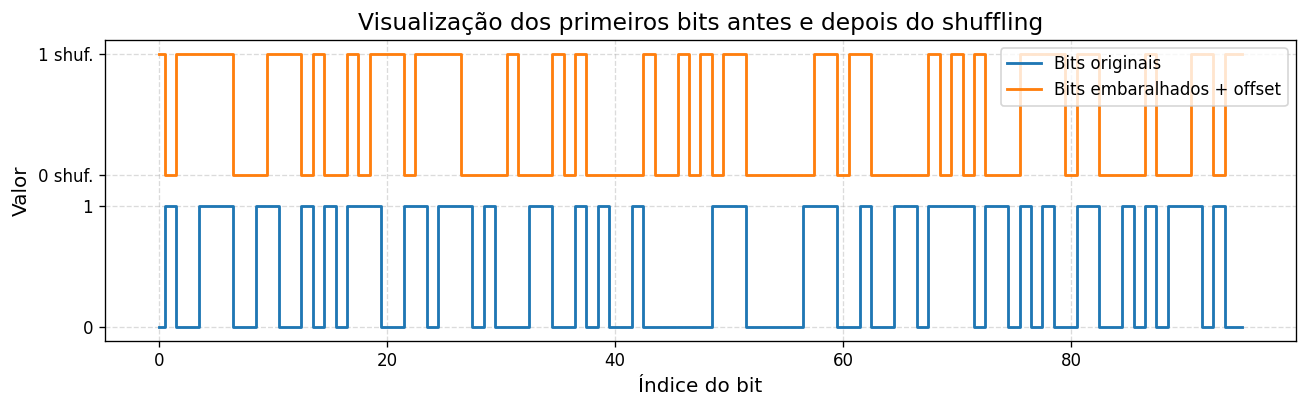

In [4]:
# Texto -> bits
TextoBits = text_to_bits(texto)

# Shuffling
TextoShuf, indices_shuffle = shuffle_bits(TextoBits, seed=seed_shuffle)

print('Mensagem original:')
print(texto)
print()
print(f'Quantidade de caracteres: {len(texto)}')
print(f'Quantidade de bits: {len(TextoBits)}')
print(f'Primeiros 32 bits originais:      {TextoBits[:32]}')
print(f'Primeiros 32 bits embaralhados:   {TextoShuf[:32]}')

n_bits_plot = min(96, len(TextoBits))
plt.figure(figsize=(11, 3.5))
plt.step(np.arange(n_bits_plot), TextoBits[:n_bits_plot], where='mid', label='Bits originais')
plt.step(np.arange(n_bits_plot), TextoShuf[:n_bits_plot] + 1.25, where='mid', label='Bits embaralhados + offset')
plt.title('Visualização dos primeiros bits antes e depois do shuffling')
plt.xlabel('Índice do bit')
plt.ylabel('Valor')
plt.yticks([0, 1, 1.25, 2.25], ['0', '1', '0 shuf.', '1 shuf.'])
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 5. Mapeamento e constelação tradicional

Nesta etapa os bits embaralhados são agrupados e transformados em símbolos. No caso da `16-QAM`, cada símbolo representa 4 bits.

A constelação tradicional mostra os pontos de decisão da modulação. Ela é importante porque permite ver se os símbolos estão bem separados e se o ruído está espalhando muito os pontos.

Modulação escolhida: 16qam
Bits por símbolo: 4
Símbolos de dados gerados: 640
Zeros adicionados para fechar grupos: 0
Primeiros 10 símbolos mapeados:
[ 0.9486833 +0.31622777j  0.31622777+0.9486833j  -0.9486833 +0.31622777j
  0.9486833 +0.9486833j  -0.31622777-0.31622777j  0.31622777-0.31622777j
  0.31622777+0.9486833j  -0.9486833 -0.31622777j -0.9486833 -0.31622777j
 -0.31622777-0.9486833j ]


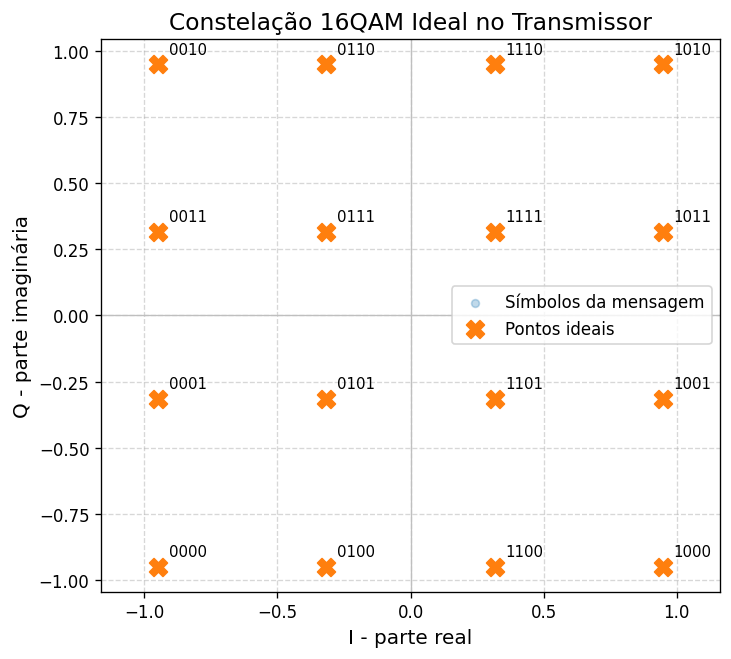

In [5]:
# Mapping dos dados
simbolos_dados, n_pad_mapping = mapear_bits(TextoShuf, Mod_format, M)
pontos_ideais, labels_ideais = obter_constelacao(Mod_format, M)

print(f'Modulação escolhida: {Mod_format}')
print(f'Bits por símbolo: {bits_por_simbolo(Mod_format, M)}')
print(f'Símbolos de dados gerados: {len(simbolos_dados)}')
print(f'Zeros adicionados para fechar grupos: {n_pad_mapping}')
print(f'Primeiros 10 símbolos mapeados:\n{simbolos_dados[:10]}')

fig, ax = plt.subplots(figsize=(6.2, 5.6))
configurar_eixo_constelacao(ax, f'Constelação {Mod_format.upper()} Ideal no Transmissor')
ax.scatter(np.real(simbolos_dados), np.imag(simbolos_dados), s=22, alpha=0.28, label='Símbolos da mensagem')
ax.scatter(np.real(pontos_ideais), np.imag(pontos_ideais), s=115, marker='X', label='Pontos ideais')
for p, lab in zip(pontos_ideais, labels_ideais):
    ax.text(np.real(p)+0.04, np.imag(p)+0.04, ''.join(map(str, lab)), fontsize=9)
ax.legend(loc='best')
plt.tight_layout()
plt.show()


### Outras constelações disponíveis

Este gráfico mostra que a função de mapeamento não ficou presa apenas na modulação principal. A mesma estrutura também permite testar modulações reais e complexas.

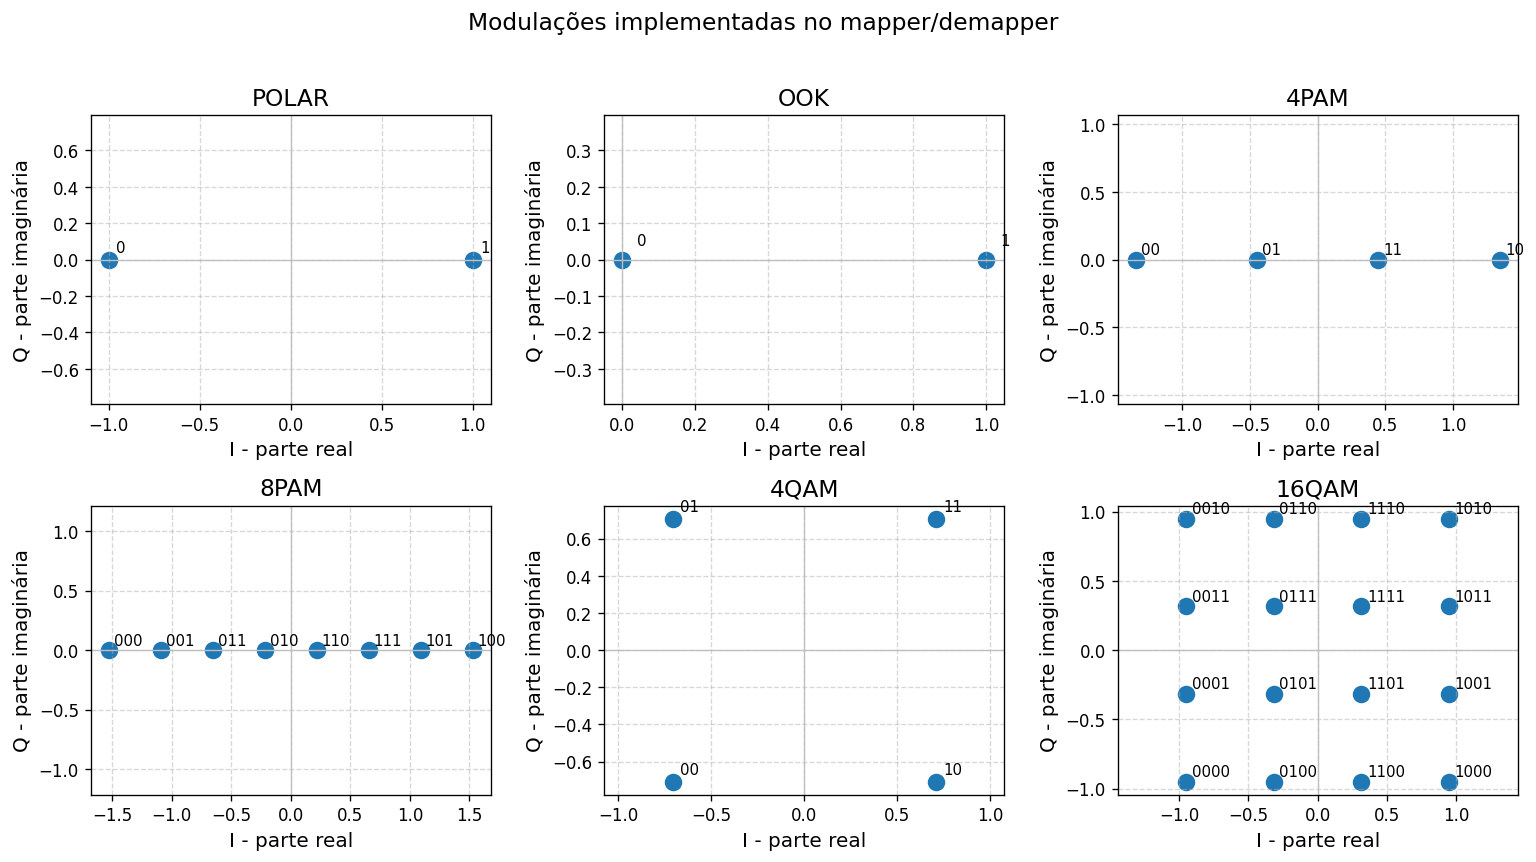

In [6]:
mods_demo = [('polar', None), ('ook', None), ('4pam', 4), ('8pam', 8), ('4qam', 4), ('16qam', 16)]
fig, axs = plt.subplots(2, 3, figsize=(13, 7))
axs = axs.ravel()
for ax, (mod_demo, M_demo) in zip(axs, mods_demo):
    pts, labs = obter_constelacao(mod_demo, M_demo)
    configurar_eixo_constelacao(ax, mod_demo.upper())
    ax.scatter(np.real(pts), np.imag(pts), s=90)
    for p, lab in zip(pts, labs):
        ax.text(np.real(p)+0.04, np.imag(p)+0.04, ''.join(map(str, lab)), fontsize=9)
plt.suptitle('Modulações implementadas no mapper/demapper', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 6. Preâmbulo e formação do quadro

Antes dos dados da mensagem, eu coloco um preâmbulo conhecido. Esse preâmbulo funciona como uma referência curta para o receptor encontrar o início do sinal recebido.

Com isso, a sincronização fica mais coerente, porque o receptor não precisa conhecer a mensagem inteira para se alinhar.

Símbolos de preâmbulo: 32
Símbolos de dados: 640
Símbolos totais do frame: 672


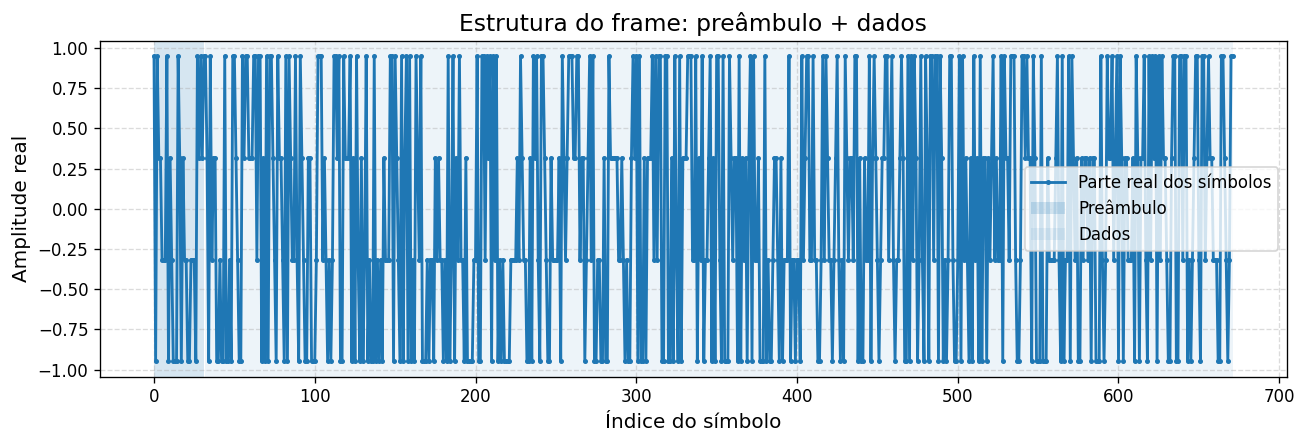

In [7]:
k = bits_por_simbolo(Mod_format, M)
rng_pre = np.random.default_rng(seed_preambulo)
bits_preambulo = rng_pre.integers(0, 2, Nsync * k)
simbolos_preambulo, _ = mapear_bits(bits_preambulo, Mod_format, M)

# Quadro transmitido: preâmbulo + dados
simbolos_frame = np.concatenate([simbolos_preambulo, simbolos_dados])

print(f'Símbolos de preâmbulo: {len(simbolos_preambulo)}')
print(f'Símbolos de dados: {len(simbolos_dados)}')
print(f'Símbolos totais do frame: {len(simbolos_frame)}')

plt.figure(figsize=(11, 3.8))
plt.plot(np.real(simbolos_frame), '.-', markersize=4, label='Parte real dos símbolos')
plt.axvspan(0, Nsync-1, alpha=0.18, label='Preâmbulo')
plt.axvspan(Nsync, len(simbolos_frame)-1, alpha=0.08, label='Dados')
plt.title('Estrutura do frame: preâmbulo + dados')
plt.xlabel('Índice do símbolo')
plt.ylabel('Amplitude real')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Formatação de pulso com K1

Aqui os símbolos passam pela sobreamostragem `K1` e depois pela formatação de pulso escolhida.

Essa etapa é importante porque transforma a sequência de símbolos em uma forma de onda, permitindo analisar o sinal no tempo e também no espectro.

Tamanho do frame em símbolos: 672
Tamanho após zero insertion K1: 5376 amostras
Tamanho após pulse shaping: 5440 amostras


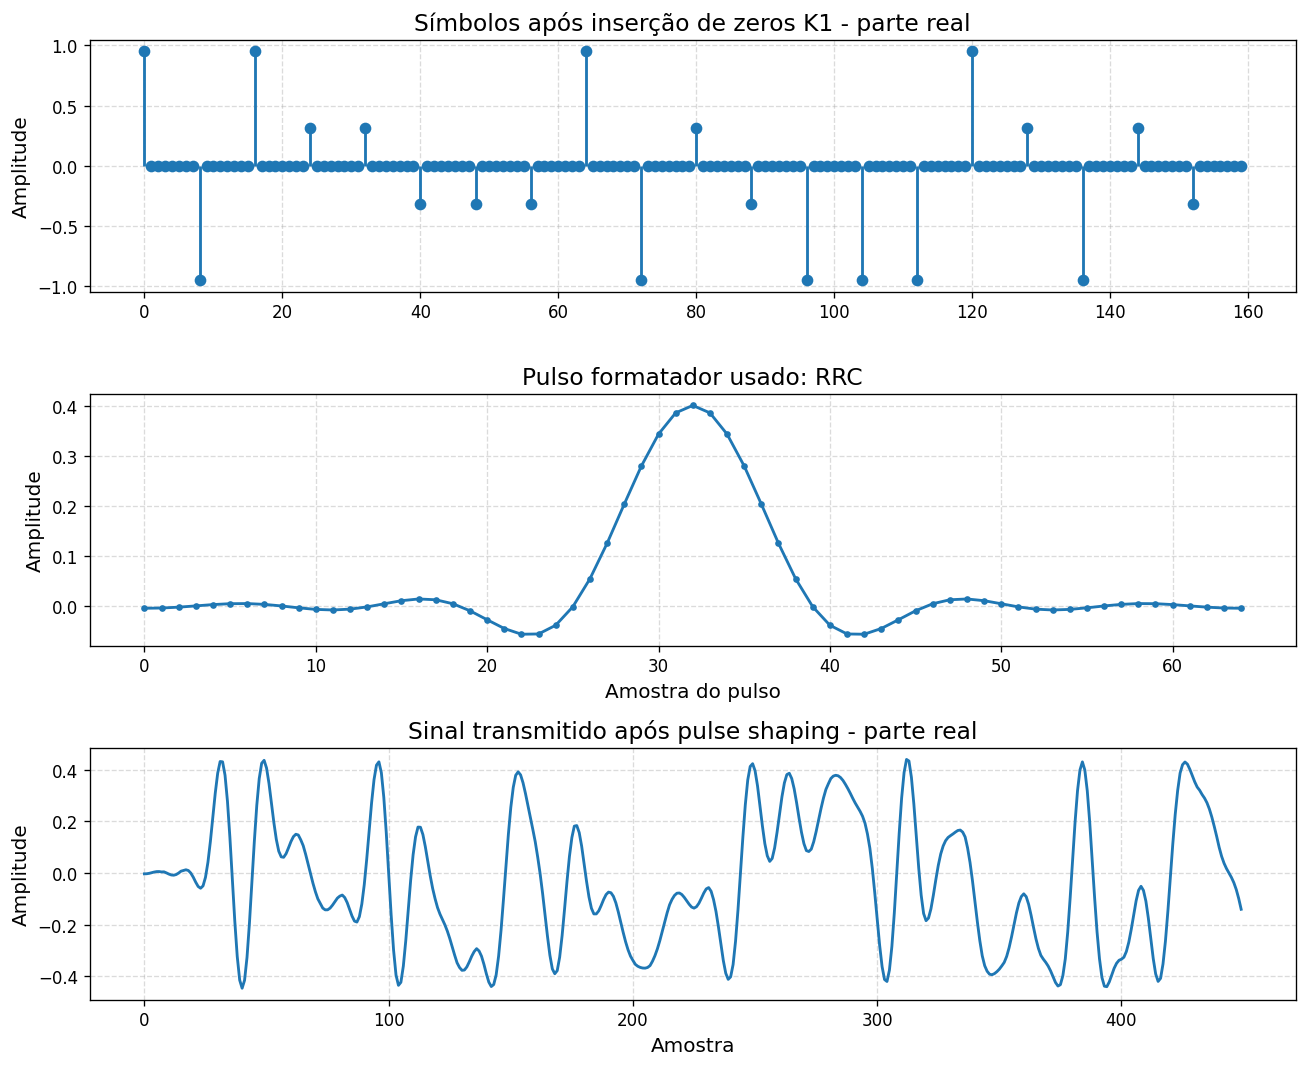

In [8]:
sinal_tx, xpad_K1, pulso = aplicar_pulse_shaping(
    simbolos_frame,
    K1=K1,
    Pulse_shape=Pulse_shape,
    roll_off=roll_off,
    span=span_rrc,
    DC=DC
)

print(f'Tamanho do frame em símbolos: {len(simbolos_frame)}')
print(f'Tamanho após zero insertion K1: {len(xpad_K1)} amostras')
print(f'Tamanho após pulse shaping: {len(sinal_tx)} amostras')

fig, axs = plt.subplots(3, 1, figsize=(11, 9), sharex=False)

n1 = min(160, len(xpad_K1))
axs[0].stem(np.arange(n1), np.real(xpad_K1[:n1]), basefmt=' ')
axs[0].set_title('Símbolos após inserção de zeros K1 - parte real')
axs[0].set_ylabel('Amplitude')

axs[1].plot(pulso, '.-')
axs[1].set_title(f'Pulso formatador usado: {Pulse_shape.upper()}')
axs[1].set_xlabel('Amostra do pulso')
axs[1].set_ylabel('Amplitude')

n2 = min(450, len(sinal_tx))
axs[2].plot(np.real(sinal_tx[:n2]))
axs[2].set_title('Sinal transmitido após pulse shaping - parte real')
axs[2].set_xlabel('Amostra')
axs[2].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

## 8. Interpolação K2 no domínio da frequência

Nesta parte eu mostro a interpolação `K2` usando o domínio da frequência.

O processo usado foi:

1. calcular a FFT do sinal já formatado por pulso;
2. inserir zeros no espectro;
3. voltar para o tempo usando IFFT;
4. obter um sinal com mais amostras.

Assim fica mais fácil visualizar a relação entre o sinal no tempo e o comportamento no domínio da frequência.

Tamanho antes do K2: 5440 amostras
Tamanho depois do K2: 21760 amostras
Fator obtido: 4.0x
Tamanho final com zeros para AWG/transmissão: 22160 amostras


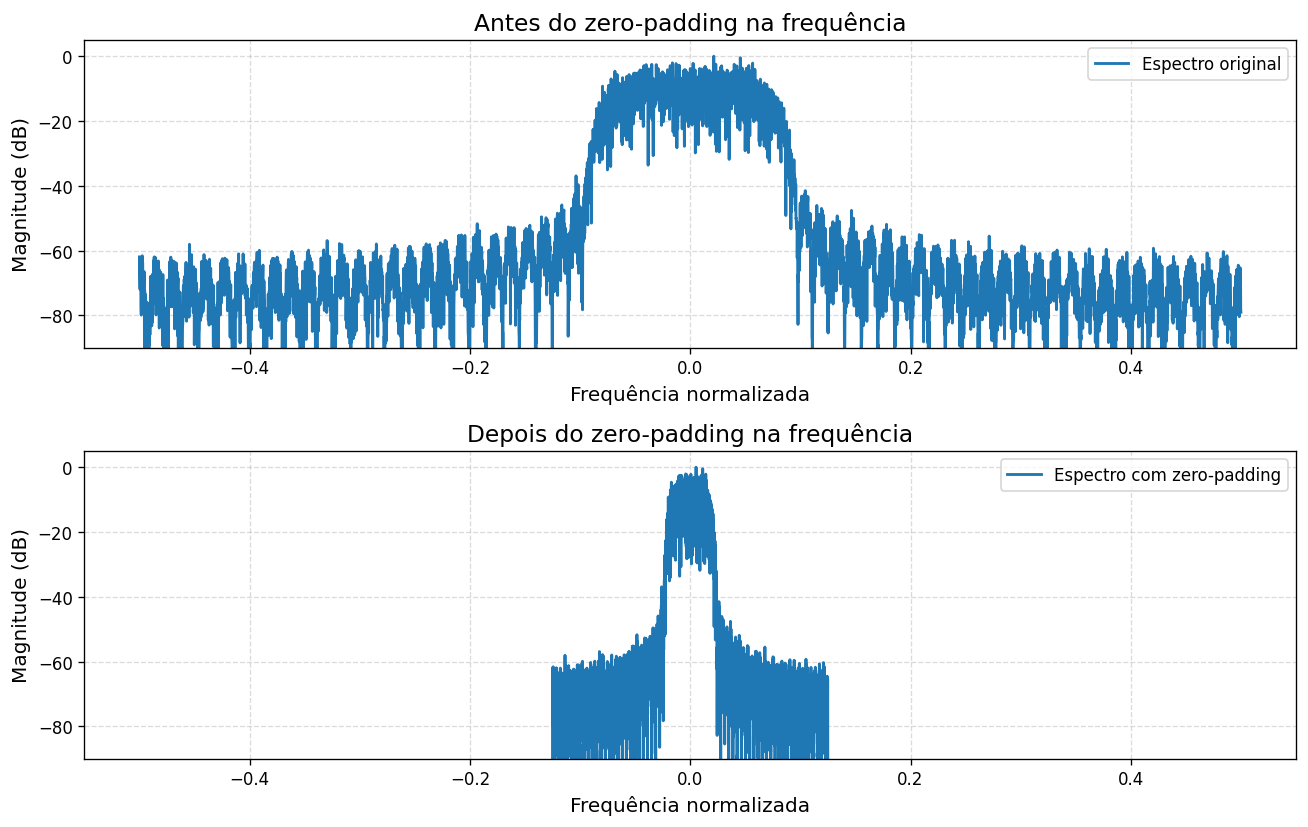

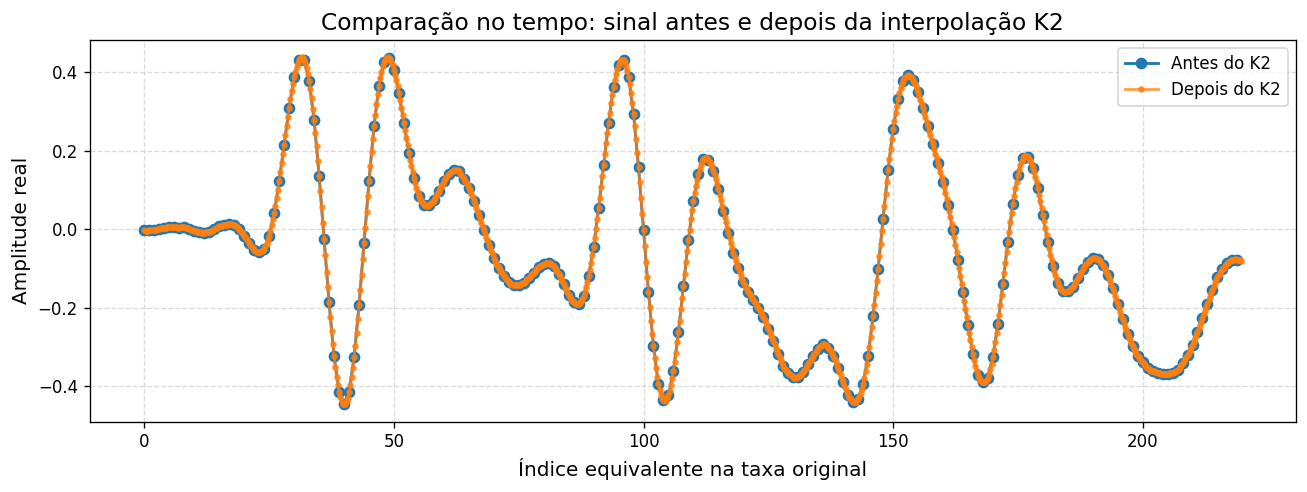

In [9]:
sinal_tx_K2, S_original, S_zero_pad = oversampling_K2_freq_zero_padding(sinal_tx, K2=K2)

# Referência de sincronização: somente o trecho do preâmbulo no sinal já interpolado.
referencia_sync = sinal_tx_K2[:Nsync * K1 * K2]

# Zeros iniciais/finais para transmissão/exportação
sinal_tx_awg = np.concatenate([
    np.zeros(Nzeros_init, dtype=complex),
    sinal_tx_K2,
    np.zeros(Nzeros_final, dtype=complex)
])

print(f'Tamanho antes do K2: {len(sinal_tx)} amostras')
print(f'Tamanho depois do K2: {len(sinal_tx_K2)} amostras')
print(f'Fator obtido: {len(sinal_tx_K2) / len(sinal_tx):.1f}x')
print(f'Tamanho final com zeros para AWG/transmissão: {len(sinal_tx_awg)} amostras')

fig, axs = plt.subplots(2, 1, figsize=(11, 7))
Nfreq_show = min(2000, len(S_zero_pad))
freq_orig = np.linspace(-0.5, 0.5, len(S_original), endpoint=False)
freq_pad = np.linspace(-0.5, 0.5, len(S_zero_pad), endpoint=False)
axs[0].plot(freq_orig, 20*np.log10(np.abs(S_original)/np.max(np.abs(S_original))+1e-12), label='Espectro original')
axs[0].set_title('Antes do zero-padding na frequência')
axs[0].set_xlabel('Frequência normalizada')
axs[0].set_ylabel('Magnitude (dB)')
axs[0].set_ylim(-90, 5)
axs[0].legend()

axs[1].plot(freq_pad, 20*np.log10(np.abs(S_zero_pad)/np.max(np.abs(S_zero_pad))+1e-12), label='Espectro com zero-padding')
axs[1].set_title('Depois do zero-padding na frequência')
axs[1].set_xlabel('Frequência normalizada')
axs[1].set_ylabel('Magnitude (dB)')
axs[1].set_ylim(-90, 5)
axs[1].legend()
plt.tight_layout()
plt.show()

n_compare = min(220, len(sinal_tx))
plt.figure(figsize=(11, 4.2))
plt.plot(np.arange(n_compare), np.real(sinal_tx[:n_compare]), 'o-', label='Antes do K2')
plt.plot(np.arange(n_compare*K2)/K2, np.real(sinal_tx_K2[:n_compare*K2]), '.-', alpha=0.75, label='Depois do K2')
plt.title('Comparação no tempo: sinal antes e depois da interpolação K2')
plt.xlabel('Índice equivalente na taxa original')
plt.ylabel('Amplitude real')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Espectro do sinal transmitido

Aqui é feita a FFT do sinal transmitido para observar como a energia do sinal fica distribuída em frequência depois da formatação de pulso e da interpolação.

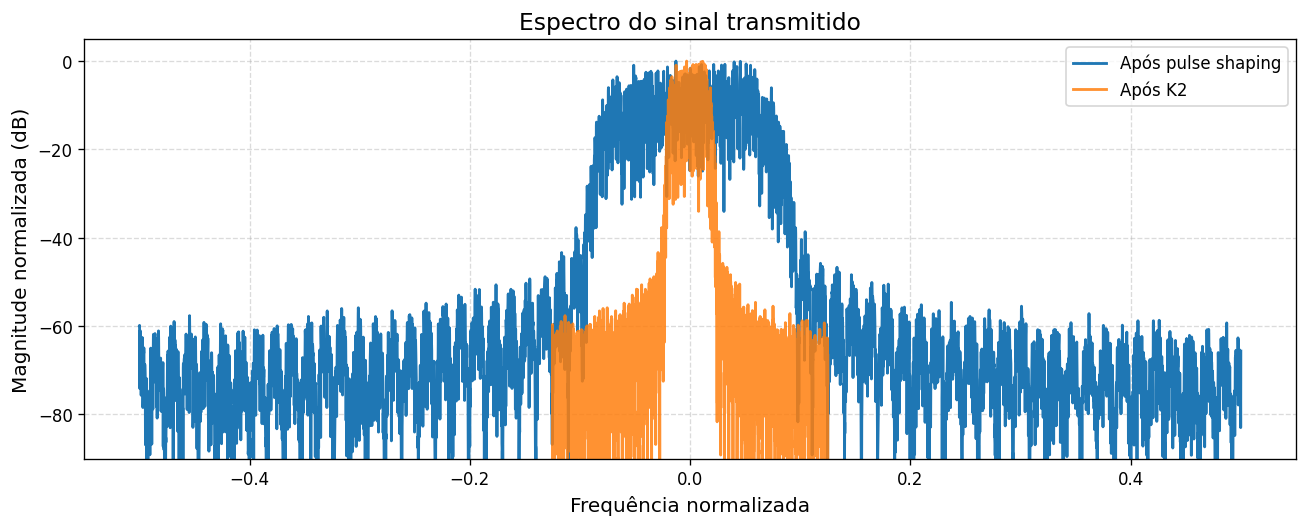

In [10]:
freq_tx, mag_tx_db = espectro_normalizado_db(sinal_tx)
freq_tx_K2, mag_tx_K2_db = espectro_normalizado_db(sinal_tx_K2)

plt.figure(figsize=(11, 4.5))
plt.plot(freq_tx, mag_tx_db, label='Após pulse shaping')
plt.plot(freq_tx_K2, mag_tx_K2_db, alpha=0.85, label='Após K2')
plt.title('Espectro do sinal transmitido')
plt.xlabel('Frequência normalizada')
plt.ylabel('Magnitude normalizada (dB)')
plt.ylim(-90, 5)
plt.legend()
plt.tight_layout()
plt.show()

## 10. Canal: ruído, distorção e atraso

Nesta simulação, o canal foi montado com três efeitos principais:

1. canal seletivo em frequência, que distorce o sinal;
2. ruído AWGN, que espalha os pontos da constelação;
3. atraso temporal `DeltaT`, que tira o sinal do alinhamento correto.

Esses efeitos deixam a recepção mais parecida com um caso real de comunicação.

Resposta do canal seletivo: [ 0.9 +0.j  0.3 +0.j -0.15+0.j]
Potência média do sinal: 1.4120e-01
Potência média do ruído: 4.4652e-04
SNR usado: 25 dB
DeltaT aplicado: 17 amostras


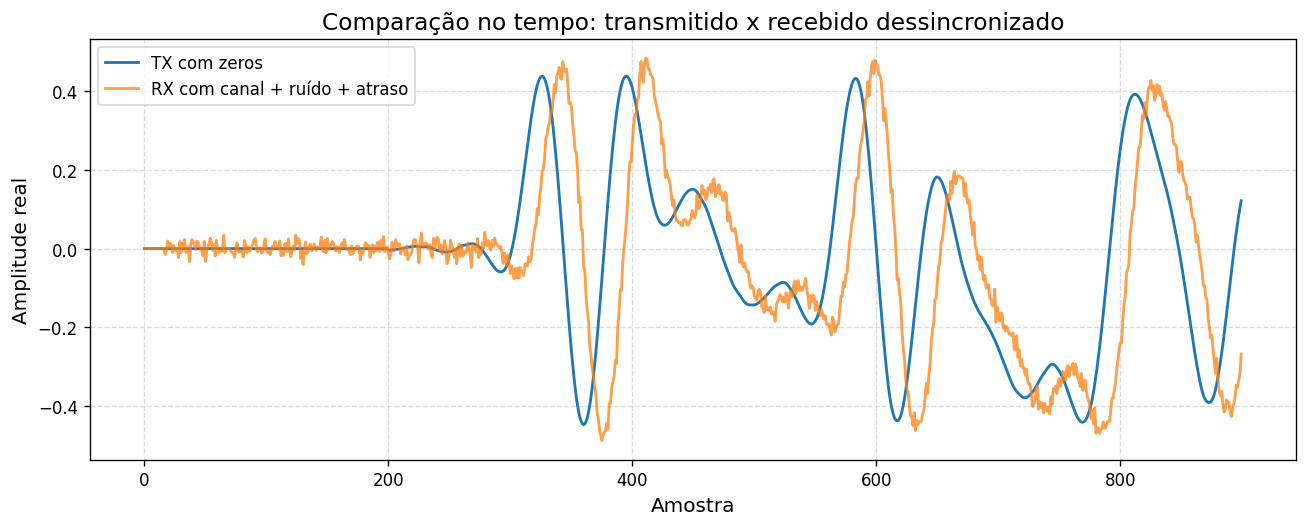

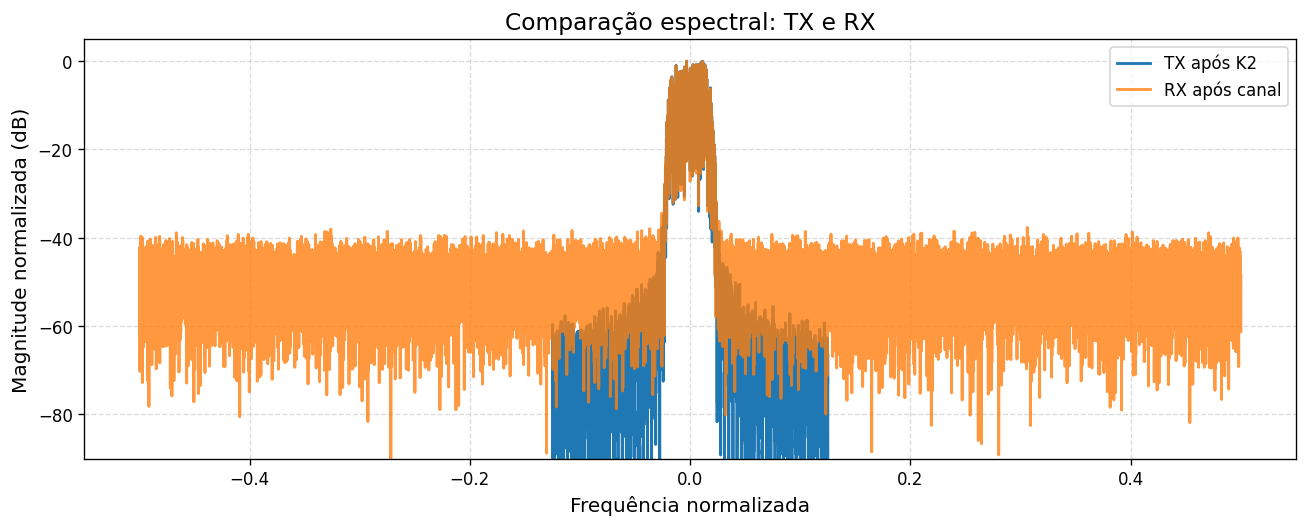

In [11]:
if USAR_CANAL_SELETIVO:
    sinal_pos_canal = canal_seletivo(sinal_tx_awg, Freq_sel_resp)
else:
    sinal_pos_canal = sinal_tx_awg.copy()

sinal_rx_awgn, ruido, Ps, Pn = canal_awgn(sinal_pos_canal, SNR_dB, seed=seed_ruido)
sinal_rx_desync = aplicar_dessincronizacao(sinal_rx_awgn, DeltaT)

print(f'Resposta do canal seletivo: {Freq_sel_resp}')
print(f'Potência média do sinal: {Ps:.4e}')
print(f'Potência média do ruído: {Pn:.4e}')
print(f'SNR usado: {SNR_dB} dB')
print(f'DeltaT aplicado: {DeltaT} amostras')

n_mostrar = min(900, len(sinal_rx_desync))
plt.figure(figsize=(11, 4.5))
plt.plot(np.real(sinal_tx_awg[:n_mostrar]), label='TX com zeros')
plt.plot(np.real(sinal_rx_desync[:n_mostrar]), alpha=0.75, label='RX com canal + ruído + atraso')
plt.title('Comparação no tempo: transmitido x recebido dessincronizado')
plt.xlabel('Amostra')
plt.ylabel('Amplitude real')
plt.legend()
plt.tight_layout()
plt.show()

freq_rx, mag_rx_db = espectro_normalizado_db(sinal_rx_awgn)
plt.figure(figsize=(11, 4.5))
plt.plot(freq_tx_K2, mag_tx_K2_db, label='TX após K2')
plt.plot(freq_rx, mag_rx_db, alpha=0.8, label='RX após canal')
plt.title('Comparação espectral: TX e RX')
plt.xlabel('Frequência normalizada')
plt.ylabel('Magnitude normalizada (dB)')
plt.ylim(-90, 5)
plt.legend()
plt.tight_layout()
plt.show()

## 11. Sincronização por preâmbulo

Nesta etapa o receptor procura o pico da correlação entre o sinal recebido e o preâmbulo conhecido.

O maior pico indica a posição mais provável do começo do quadro. A partir disso, o receptor consegue remover o atraso aplicado pelo canal.

DeltaT aplicado: 17
Zeros iniciais antes do quadro: 200
Atraso esperado aproximado: 217
Atraso estimado pela sincronização: 216


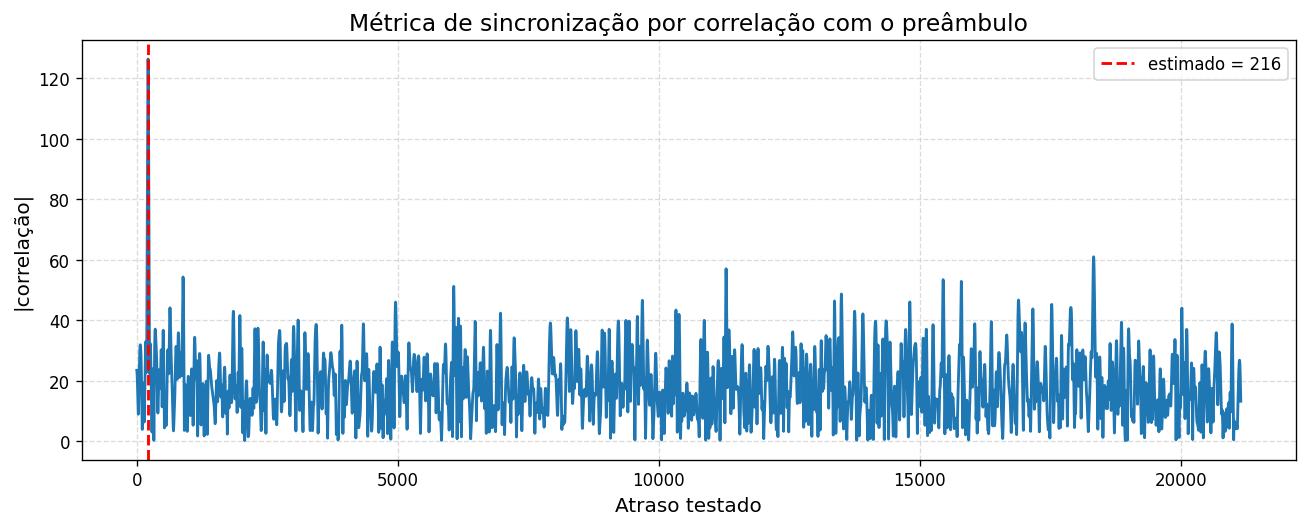

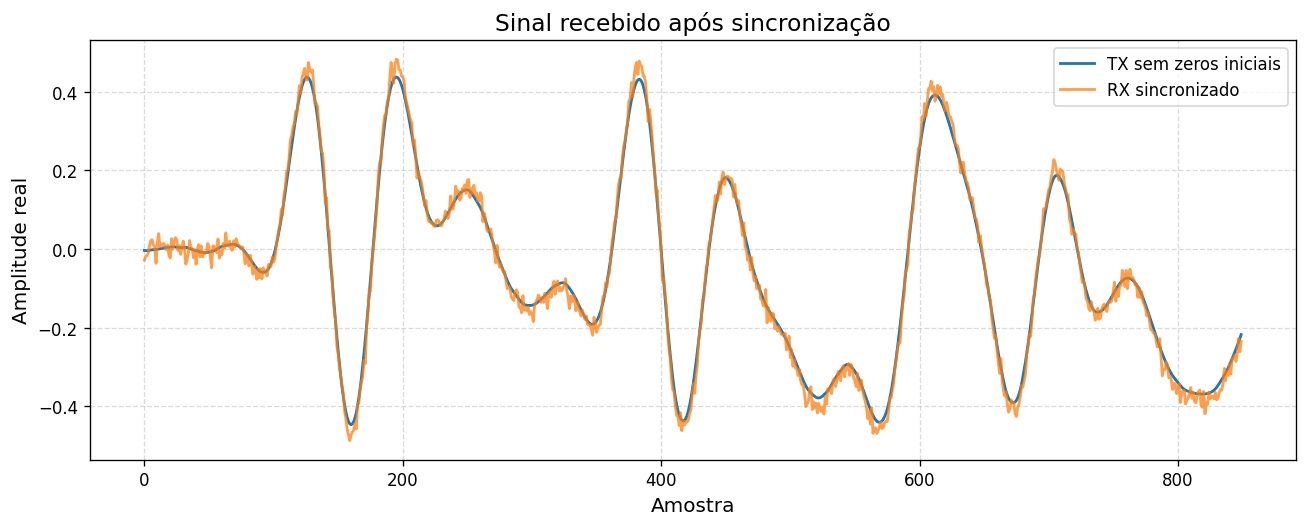

In [12]:
atraso_estimado, metrica_sync = sincronizar_por_preambulo(sinal_rx_desync, referencia_sync)

sinal_rx_sync = sinal_rx_desync[atraso_estimado : atraso_estimado + len(sinal_tx_K2)]
if len(sinal_rx_sync) < len(sinal_tx_K2):
    sinal_rx_sync = np.pad(sinal_rx_sync, (0, len(sinal_tx_K2) - len(sinal_rx_sync)))

print(f'DeltaT aplicado: {DeltaT}')
print(f'Zeros iniciais antes do quadro: {Nzeros_init}')
print(f'Atraso esperado aproximado: {DeltaT + Nzeros_init}')
print(f'Atraso estimado pela sincronização: {atraso_estimado}')

plt.figure(figsize=(11, 4.5))
plt.plot(metrica_sync)
plt.axvline(atraso_estimado, color='r', linestyle='--', label=f'estimado = {atraso_estimado}')
plt.title('Métrica de sincronização por correlação com o preâmbulo')
plt.xlabel('Atraso testado')
plt.ylabel('|correlação|')
plt.legend()
plt.tight_layout()
plt.show()

n_mostrar = min(850, len(sinal_rx_sync), len(sinal_tx_K2))
plt.figure(figsize=(11, 4.5))
plt.plot(np.real(sinal_tx_K2[:n_mostrar]), label='TX sem zeros iniciais')
plt.plot(np.real(sinal_rx_sync[:n_mostrar]), alpha=0.75, label='RX sincronizado')
plt.title('Sinal recebido após sincronização')
plt.xlabel('Amostra')
plt.ylabel('Amplitude real')
plt.legend()
plt.tight_layout()
plt.show()

## 12. Equalização, downsampling, filtro casado e amostragem

Depois da sincronização, o receptor ainda precisa corrigir a distorção causada pelo canal seletivo em frequência.

Em seguida, o sinal volta da taxa `K2`, passa pelo filtro casado e é amostrado no melhor instante possível. Esse instante é escolhido usando o preâmbulo, porque nele o receptor já sabe quais símbolos deveriam aparecer.

Atraso de amostragem escolhido: 64
Ganho/fase estimado pelo preâmbulo: 0.9962+0.0102j
Erro médio no preâmbulo após correção: 2.0172e-03
Símbolos de dados recuperados: 640


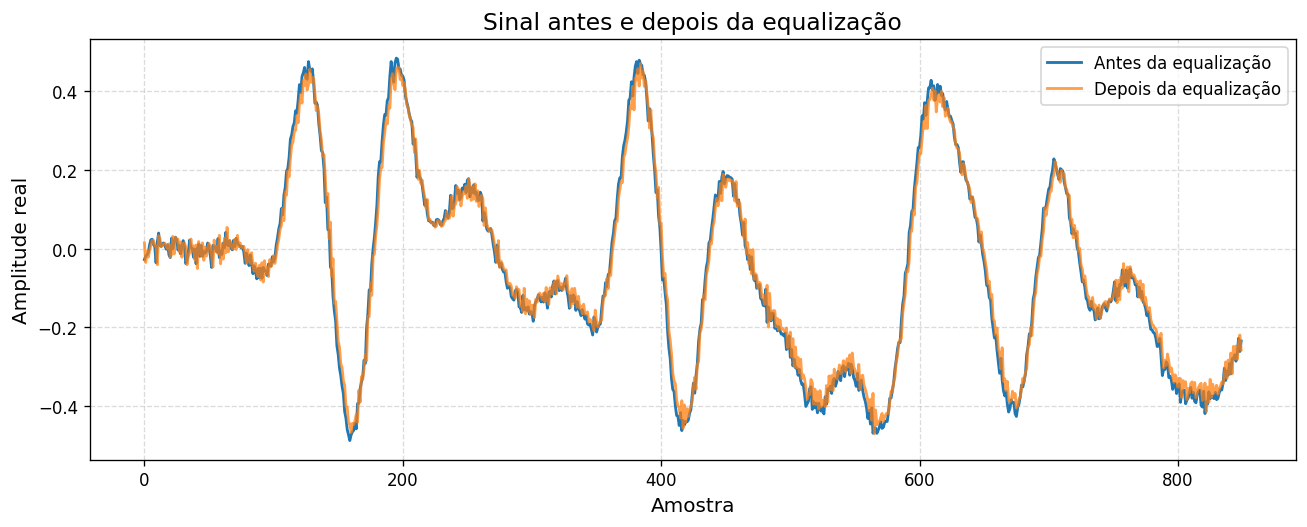

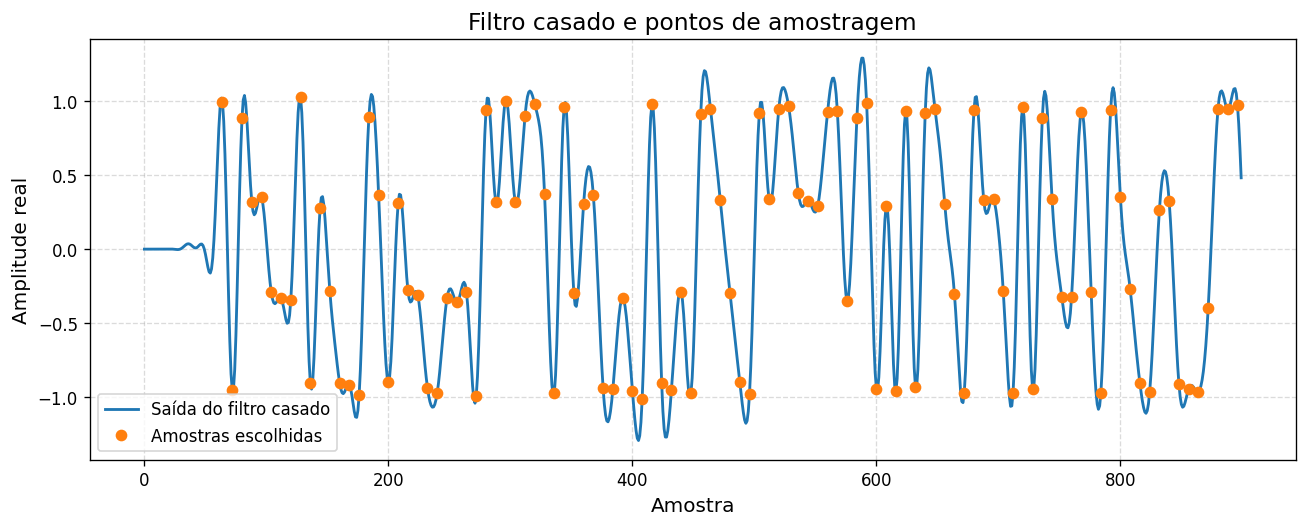

In [13]:
if USAR_CANAL_SELETIVO and USAR_EQUALIZADOR:
    sinal_rx_equalizado = equalizar_freq_mode_same(sinal_rx_sync, Freq_sel_resp, eps=1e-3)
else:
    sinal_rx_equalizado = sinal_rx_sync.copy()

sinal_rx_down = downsampling_K2(sinal_rx_equalizado, K2, fase=0)

simbolos_rx_frame, sinal_rx_filtrado, atraso_amostragem, ganho_estimado, erro_pre = filtro_casado_e_amostragem_com_preambulo(
    sinal_rx_down,
    pulso,
    K1,
    simbolos_preambulo,
    n_simbolos_total=len(simbolos_frame)
)

simbolos_rx_dados = simbolos_rx_frame[Nsync : Nsync + len(simbolos_dados)]

print(f'Atraso de amostragem escolhido: {atraso_amostragem}')
print(f'Ganho/fase estimado pelo preâmbulo: {ganho_estimado:.4f}')
print(f'Erro médio no preâmbulo após correção: {erro_pre:.4e}')
print(f'Símbolos de dados recuperados: {len(simbolos_rx_dados)}')

n_mostrar = min(850, len(sinal_rx_sync), len(sinal_rx_equalizado))
plt.figure(figsize=(11, 4.5))
plt.plot(np.real(sinal_rx_sync[:n_mostrar]), label='Antes da equalização')
plt.plot(np.real(sinal_rx_equalizado[:n_mostrar]), alpha=0.75, label='Depois da equalização')
plt.title('Sinal antes e depois da equalização')
plt.xlabel('Amostra')
plt.ylabel('Amplitude real')
plt.legend()
plt.tight_layout()
plt.show()

n_mostrar_filtro = min(900, len(sinal_rx_filtrado))
indices = np.arange(atraso_amostragem, n_mostrar_filtro, K1)
plt.figure(figsize=(11, 4.5))
plt.plot(np.real(sinal_rx_filtrado[:n_mostrar_filtro]), label='Saída do filtro casado')
plt.plot(indices, np.real(sinal_rx_filtrado[indices]), 'o', label='Amostras escolhidas')
plt.title('Filtro casado e pontos de amostragem')
plt.xlabel('Amostra')
plt.ylabel('Amplitude real')
plt.legend()
plt.tight_layout()
plt.show()

## 13. Diagrama de olho

O diagrama de olho foi colocado para mostrar a qualidade do sinal nos instantes de decisão.

Como a modulação principal é complexa, o gráfico é feito separando as componentes **I** e **Q**. Assim fica mais fácil observar se o sinal está com boa abertura ou se existe muita interferência entre símbolos.

Nesta parte aparecem dois casos:

- sinal transmitido depois da formatação de pulso;
- sinal recebido depois da sincronização, equalização e filtro casado.

Quanto mais aberto estiver o olho, melhor tende a ser a decisão dos símbolos no receptor.

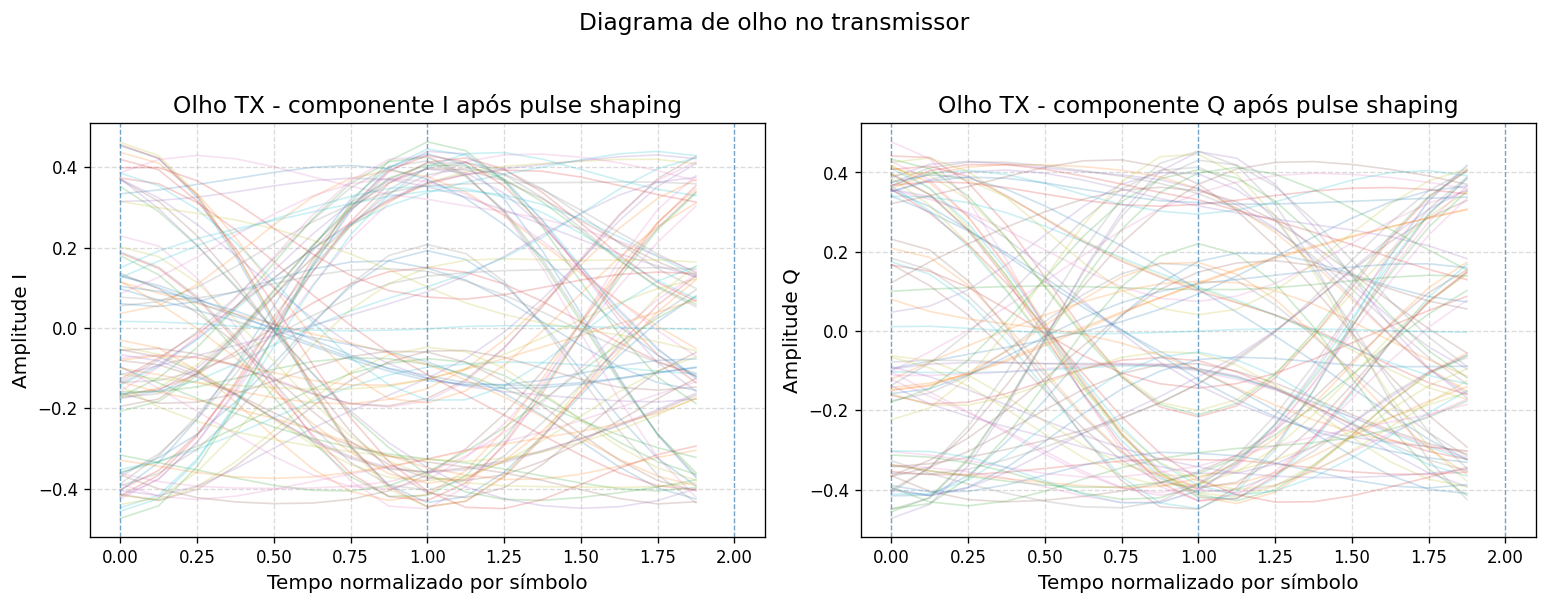

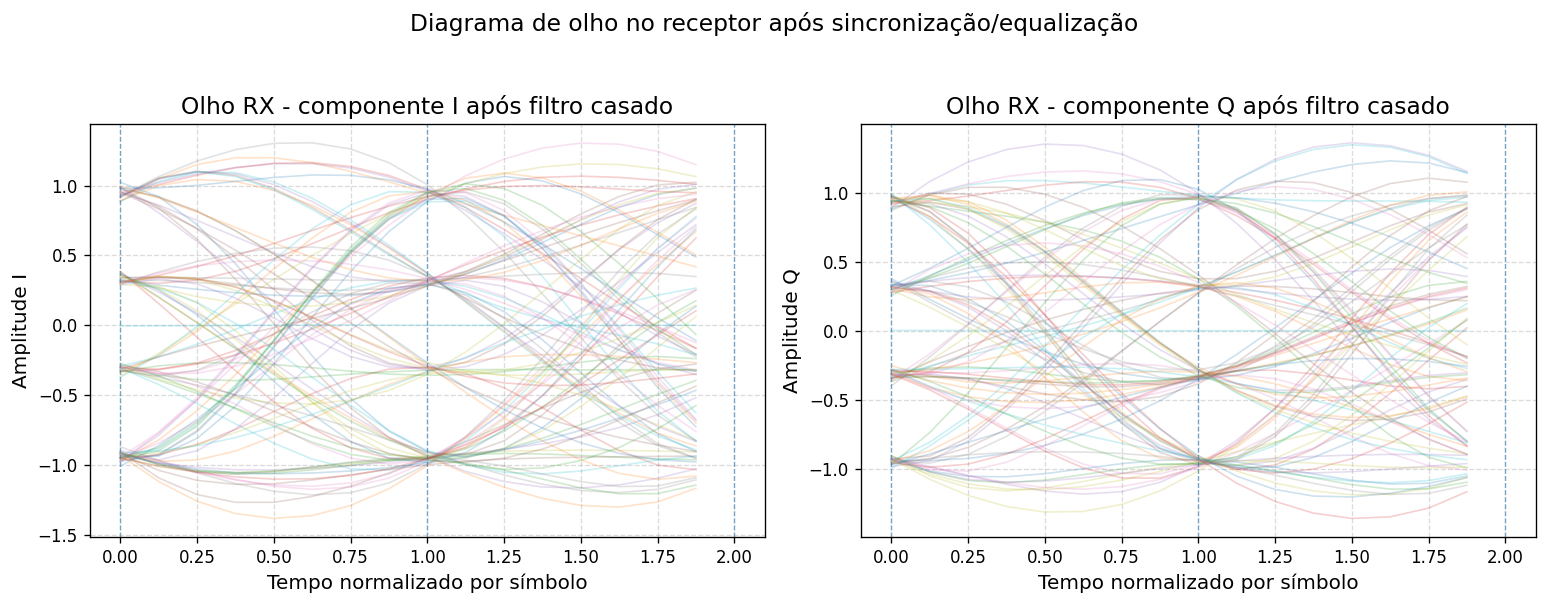

In [14]:
# =========================================================
# DIAGRAMA DE OLHO
# =========================================================

def plot_eye_component(ax, sinal, sps, titulo, componente='real', n_tracos=90,
                       simbolos_por_traco=2, offset=0, inicio_simbolo=8):
    """Plota diagrama de olho para a parte real ou imaginária de um sinal."""
    sinal = np.asarray(sinal, dtype=complex)
    amostras_por_traco = int(simbolos_por_traco * sps)
    if amostras_por_traco <= 0 or len(sinal) <= amostras_por_traco:
        ax.text(0.5, 0.5, 'Sinal curto para diagrama de olho', ha='center', va='center')
        ax.set_title(titulo)
        return

    if componente.lower() in ['imag', 'q', 'imaginaria', 'imaginário']:
        y = np.imag(sinal)
        ylabel = 'Amplitude Q'
    else:
        y = np.real(sinal)
        ylabel = 'Amplitude I'

    primeiro = int(offset + inicio_simbolo * sps)
    primeiro = max(0, min(primeiro, len(y) - amostras_por_traco - 1))
    inicios = np.arange(primeiro, len(y) - amostras_por_traco, sps, dtype=int)

    if len(inicios) == 0:
        ax.text(0.5, 0.5, 'Sem segmentos suficientes', ha='center', va='center')
        ax.set_title(titulo)
        return

    if len(inicios) > n_tracos:
        idx = np.linspace(0, len(inicios) - 1, n_tracos).astype(int)
        inicios = inicios[idx]

    t_eye = np.arange(amostras_por_traco) / sps
    for ini in inicios:
        ax.plot(t_eye, y[ini:ini + amostras_por_traco], alpha=0.22, linewidth=1.0)

    # Linhas verticais indicando instantes de símbolo dentro da janela de 2 símbolos
    for ksym in range(simbolos_por_traco + 1):
        ax.axvline(ksym, linestyle='--', linewidth=0.8, alpha=0.55)

    ax.set_title(titulo)
    ax.set_xlabel('Tempo normalizado por símbolo')
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle='--', alpha=0.45)


# Diagrama de olho no transmissor: sinal após pulse shaping, antes do canal.
fig, axs = plt.subplots(1, 2, figsize=(13, 4.8))
plot_eye_component(axs[0], sinal_tx, K1, 'Olho TX - componente I após pulse shaping', 'real', offset=0)
plot_eye_component(axs[1], sinal_tx, K1, 'Olho TX - componente Q após pulse shaping', 'imag', offset=0)
plt.suptitle('Diagrama de olho no transmissor', y=1.04, fontsize=14)
plt.tight_layout()
plt.show()

# Diagrama de olho no receptor: depois de sincronização, equalização e filtro casado.
# O offset usa a fase de amostragem escolhida pelo preâmbulo.
fig, axs = plt.subplots(1, 2, figsize=(13, 4.8))
plot_eye_component(axs[0], sinal_rx_filtrado, K1, 'Olho RX - componente I após filtro casado', 'real', offset=atraso_amostragem)
plot_eye_component(axs[1], sinal_rx_filtrado, K1, 'Olho RX - componente Q após filtro casado', 'imag', offset=atraso_amostragem)
plt.suptitle('Diagrama de olho no receptor após sincronização/equalização', y=1.04, fontsize=14)
plt.tight_layout()
plt.show()


## 14. Constelação tradicional e trajetória I/Q

Aqui eu deixei duas formas de olhar o sinal no plano complexo.

A **constelação tradicional** mostra os pontos de decisão. Ela é melhor para ver a dispersão causada pelo ruído e comparar os símbolos recebidos com os pontos ideais.

A **trajetória I/Q** liga amostras consecutivas. Esse gráfico ajuda a visualizar como o sinal caminha entre os símbolos depois da interpolação, da filtragem e do canal.

Então os dois gráficos se complementam: um mostra a decisão dos símbolos e o outro mostra a evolução do sinal no tempo.

Atraso de amostragem sem equalização: 64
Erro médio no preâmbulo sem equalização: 3.5040e-04
Erro médio no preâmbulo com equalização: 2.0172e-03


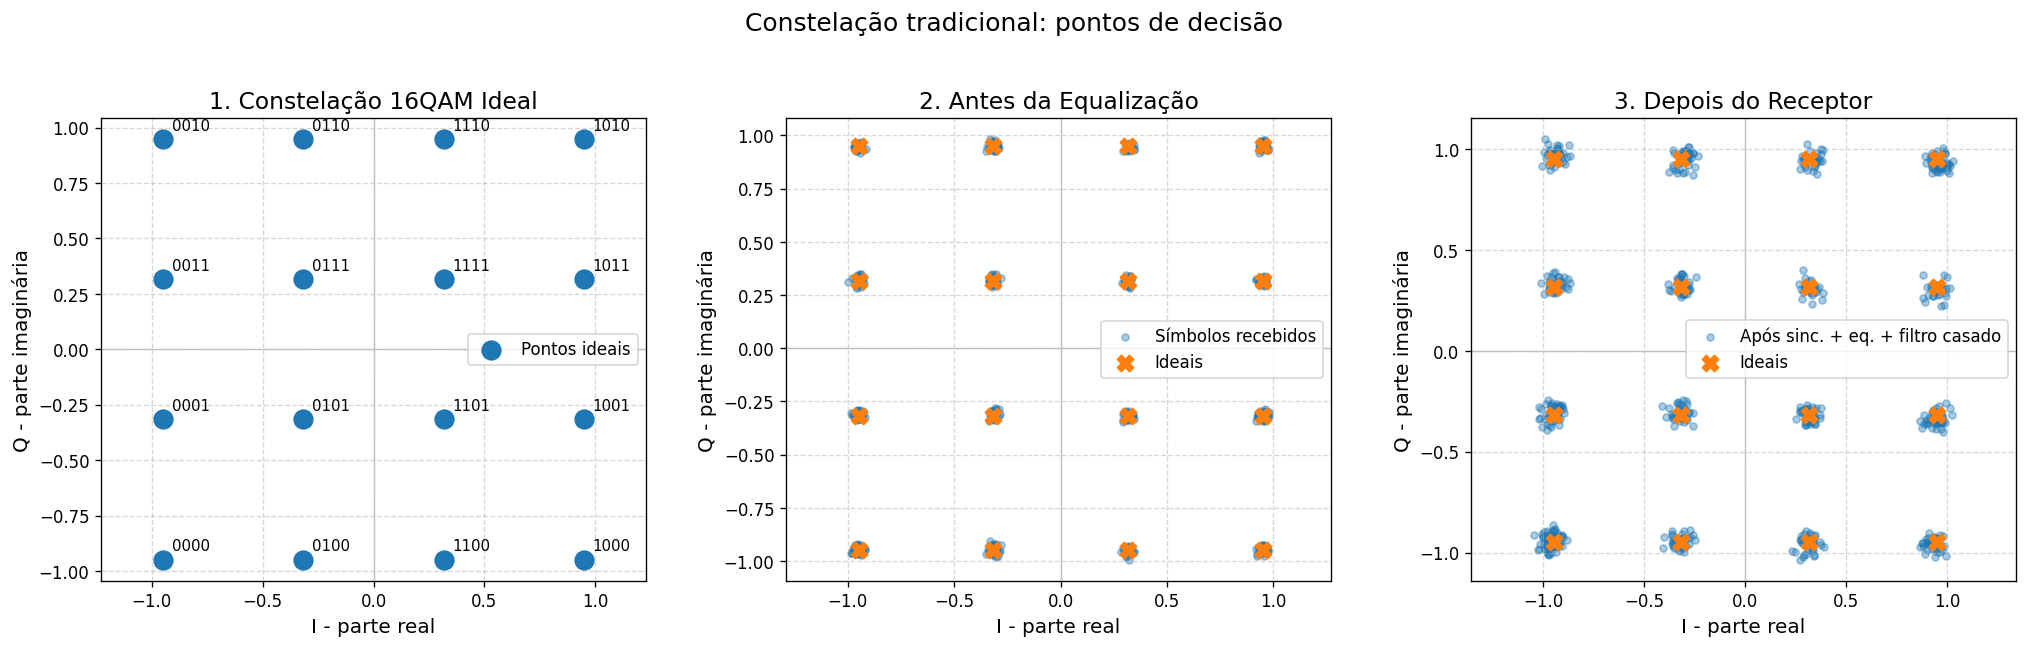

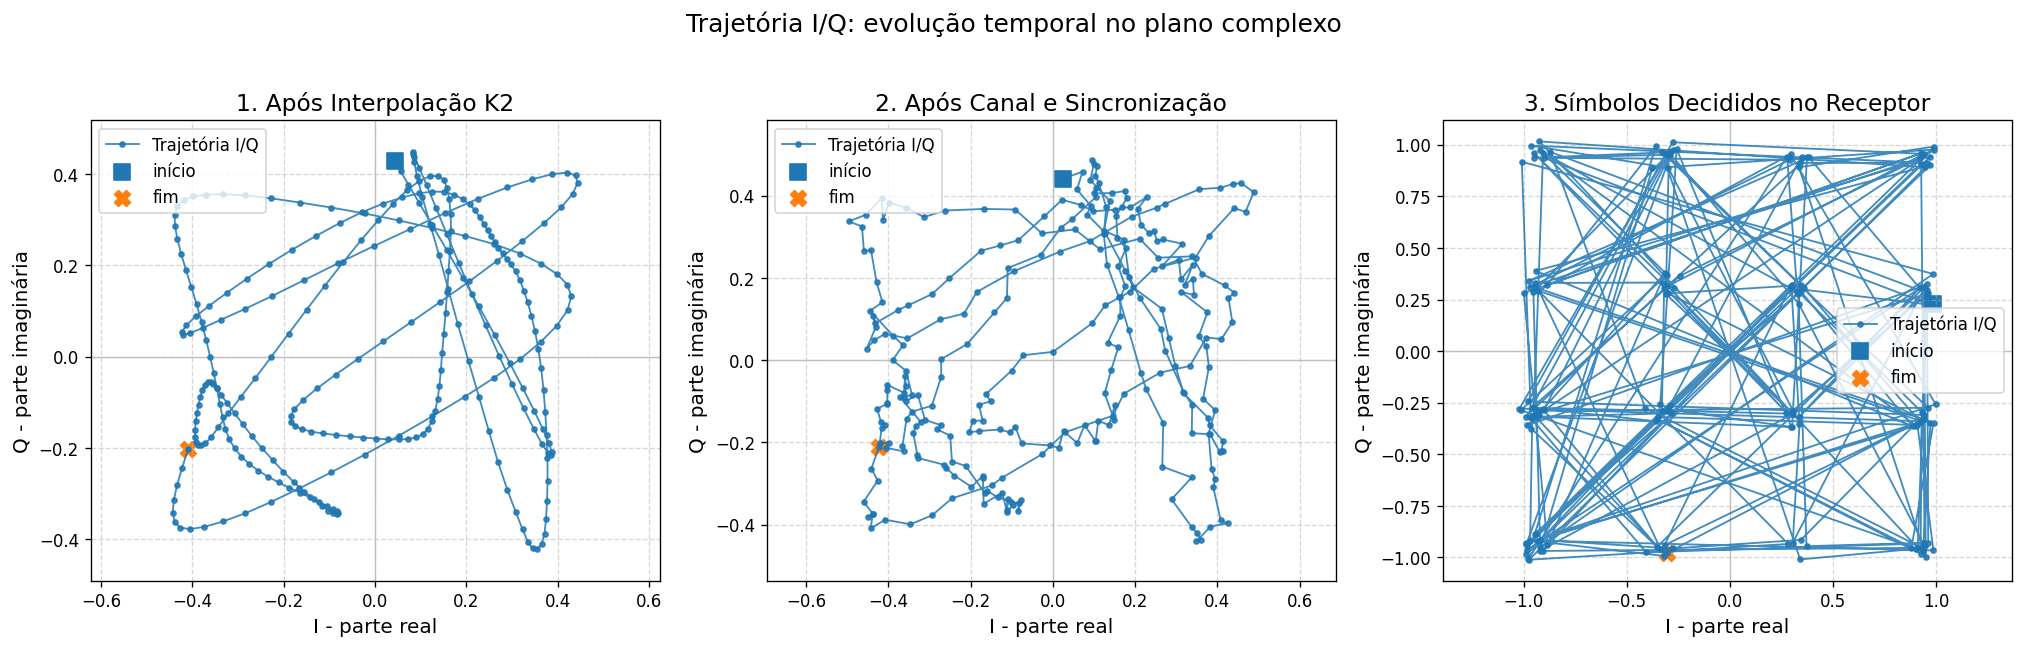

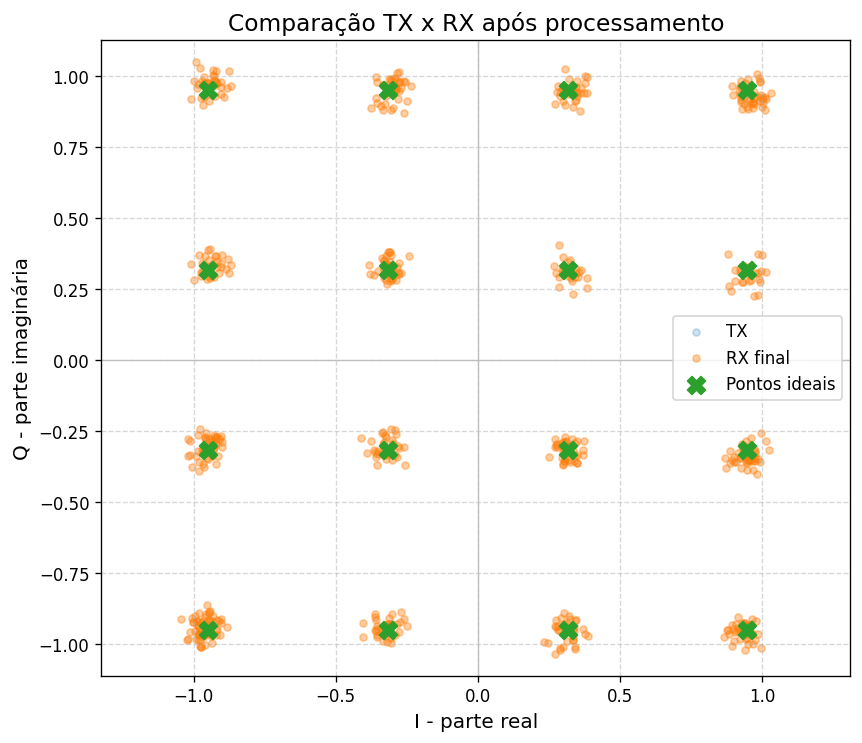

In [15]:

# ---------------------------------------------------------
# Símbolos antes da equalização, para comparar com a saída final
# ---------------------------------------------------------
# Aqui usamos o sinal já sincronizado, mas ainda sem o equalizador de canal.
rx_down_sem_eq = downsampling_K2(sinal_rx_sync, K2, fase=0)
simbolos_rx_frame_sem_eq, _, atraso_sem_eq, ganho_sem_eq, erro_pre_sem_eq = filtro_casado_e_amostragem_com_preambulo(
    rx_down_sem_eq,
    pulso,
    K1,
    simbolos_preambulo,
    n_simbolos_total=len(simbolos_frame)
)
simbolos_rx_dados_sem_eq = simbolos_rx_frame_sem_eq[Nsync : Nsync + len(simbolos_dados)]

print(f'Atraso de amostragem sem equalização: {atraso_sem_eq}')
print(f'Erro médio no preâmbulo sem equalização: {erro_pre_sem_eq:.4e}')
print(f'Erro médio no preâmbulo com equalização: {erro_pre:.4e}')

# ---------------------------------------------------------
# 1) Constelação tradicional: pontos de decisão
# ---------------------------------------------------------
fig, axs = plt.subplots(1, 3, figsize=(17, 5.2))

configurar_eixo_constelacao(axs[0], f'1. Constelação {Mod_format.upper()} Ideal')
axs[0].scatter(np.real(pontos_ideais), np.imag(pontos_ideais), s=125, marker='o', label='Pontos ideais')
for p, lab in zip(pontos_ideais, labels_ideais):
    axs[0].text(np.real(p)+0.04, np.imag(p)+0.04, ''.join(map(str, lab)), fontsize=9)
axs[0].legend(loc='best')

configurar_eixo_constelacao(axs[1], '2. Antes da Equalização')
axs[1].scatter(np.real(simbolos_rx_dados_sem_eq), np.imag(simbolos_rx_dados_sem_eq), s=18, alpha=0.38, label='Símbolos recebidos')
axs[1].scatter(np.real(pontos_ideais), np.imag(pontos_ideais), s=95, marker='X', label='Ideais')
axs[1].legend(loc='best')

configurar_eixo_constelacao(axs[2], '3. Depois do Receptor')
axs[2].scatter(np.real(simbolos_rx_dados), np.imag(simbolos_rx_dados), s=18, alpha=0.38, label='Após sinc. + eq. + filtro casado')
axs[2].scatter(np.real(pontos_ideais), np.imag(pontos_ideais), s=95, marker='X', label='Ideais')
axs[2].legend(loc='best')

plt.suptitle('Constelação tradicional: pontos de decisão', y=1.03, fontsize=15)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2) Trajetória I/Q: evolução do sinal no plano complexo
# ---------------------------------------------------------
def plot_trajetoria_iq(ax, sinal, titulo, n=260, passo=1):
    sinal = np.asarray(sinal, dtype=complex).ravel()[::passo]
    sinal = sinal[:min(n, len(sinal))]
    configurar_eixo_constelacao(ax, titulo)
    ax.plot(np.real(sinal), np.imag(sinal), '-o', markersize=3, linewidth=1.1, alpha=0.85, label='Trajetória I/Q')
    ax.scatter(np.real(sinal[0]), np.imag(sinal[0]), s=90, marker='s', label='início')
    ax.scatter(np.real(sinal[-1]), np.imag(sinal[-1]), s=90, marker='X', label='fim')
    ax.legend(loc='best')

fig, axs = plt.subplots(1, 3, figsize=(17, 5.2))

# Retiramos os primeiros pontos do preâmbulo para evitar uma figura muito carregada.
inicio_traj = Nsync * K1 * K2
plot_trajetoria_iq(axs[0], sinal_tx_K2[inicio_traj:], '1. Após Interpolação K2', n=280, passo=2)
plot_trajetoria_iq(axs[1], sinal_rx_sync[inicio_traj:], '2. Após Canal e Sincronização', n=280, passo=2)
plot_trajetoria_iq(axs[2], simbolos_rx_dados[:160], '3. Símbolos Decididos no Receptor', n=160, passo=1)

plt.suptitle('Trajetória I/Q: evolução temporal no plano complexo', y=1.03, fontsize=15)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3) Comparação direta TX x RX no mesmo plano
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.2, 6.3))
configurar_eixo_constelacao(ax, 'Comparação TX x RX após processamento')
ax.scatter(np.real(simbolos_dados), np.imag(simbolos_dados), s=18, alpha=0.22, label='TX')
ax.scatter(np.real(simbolos_rx_dados), np.imag(simbolos_rx_dados), s=18, alpha=0.38, label='RX final')
ax.scatter(np.real(pontos_ideais), np.imag(pontos_ideais), s=115, marker='X', label='Pontos ideais')
ax.legend(loc='best')
plt.tight_layout()
plt.show()


## 15. Demapping, deshuffling e recuperação do texto

Nesta etapa os símbolos recebidos são convertidos novamente para bits.

Depois disso, o deshuffling desfaz o embaralhamento aplicado no transmissor e os bits são convertidos de volta para texto.

O ponto importante é que essa recuperação acontece depois do canal, da sincronização, da equalização e do filtro casado.

Texto recuperado:
Neste projeto, a mensagem de texto não é simplesmente copiada para o receptor. Nós simulamos o envio real: o texto é convertido em bits, passa por um canal com ruído e atraso, e o nosso receptor faz todo o trabalho de sincronizar e equalizar o sinal degradado para recuperar a mensagem original de forma autêntica.

BER final: 0.0000e+00
Número de bits errados: 0
Texto recuperado corretamente? True
✅ Sistema recuperou a mensagem corretamente.


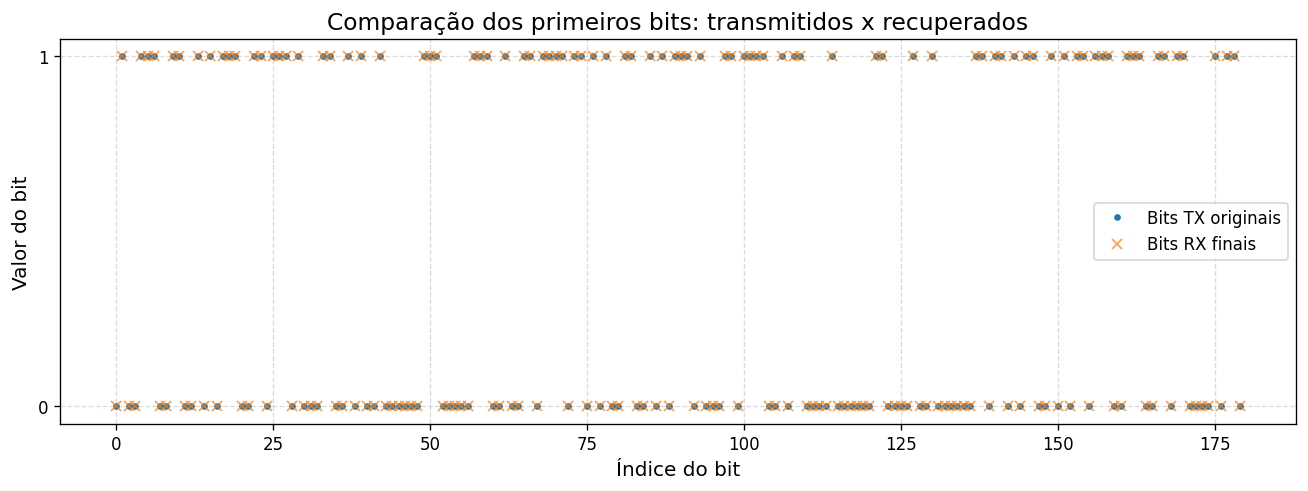

In [16]:
BitsRxShuf_com_pad = demapear_simbolos(simbolos_rx_dados, Mod_format, M)
BitsRxShuf = BitsRxShuf_com_pad[:len(TextoShuf)]
BitsRx = deshuffle_bits(BitsRxShuf, indices_shuffle)
BitsRx = BitsRx[:len(TextoBits)]

texto_recuperado = bits_to_text(BitsRx)
BER_final = np.mean(BitsRx != TextoBits)
n_erros = int(np.sum(BitsRx != TextoBits))

print('Texto recuperado:')
print(texto_recuperado)
print()
print(f'BER final: {BER_final:.4e}')
print(f'Número de bits errados: {n_erros}')
print(f'Texto recuperado corretamente? {texto_recuperado == texto}')

status = '✅ Sistema recuperou a mensagem corretamente.' if texto_recuperado == texto else '⚠️ Sistema apresentou erro na mensagem recuperada.'
print(status)

n_mostrar = min(180, len(TextoBits), len(BitsRx))
plt.figure(figsize=(11, 4.2))
plt.plot(TextoBits[:n_mostrar], '.', label='Bits TX originais')
plt.plot(BitsRx[:n_mostrar], 'x', alpha=0.75, label='Bits RX finais')
plt.title('Comparação dos primeiros bits: transmitidos x recuperados')
plt.xlabel('Índice do bit')
plt.ylabel('Valor do bit')
plt.yticks([0, 1])
plt.legend()
plt.tight_layout()
plt.show()

## 16. BER em função da SNR

Nesta parte a simulação é repetida para vários valores de SNR.

Para cada ponto da curva, a cadeia completa é usada novamente:

**canal → atraso → sincronização → equalização → filtro casado → demapping → deshuffling → BER.**

Assim a BER é calculada de forma mais justa, porque considera o receptor completo e não um sinal limpo antes do canal.

SNR =  0 dB -> BER médio = 1.4629e-01, erros médios = 374.5
SNR =  3 dB -> BER médio = 8.7695e-02, erros médios = 224.5
SNR =  6 dB -> BER médio = 3.4180e-02, erros médios = 87.5
SNR =  9 dB -> BER médio = 6.2500e-03, erros médios = 16.0
SNR = 12 dB -> BER médio = 0.0000e+00, erros médios = 0.0
SNR = 15 dB -> BER médio = 0.0000e+00, erros médios = 0.0
SNR = 18 dB -> BER médio = 0.0000e+00, erros médios = 0.0
SNR = 21 dB -> BER médio = 0.0000e+00, erros médios = 0.0
SNR = 24 dB -> BER médio = 0.0000e+00, erros médios = 0.0
SNR = 27 dB -> BER médio = 0.0000e+00, erros médios = 0.0
SNR = 30 dB -> BER médio = 0.0000e+00, erros médios = 0.0


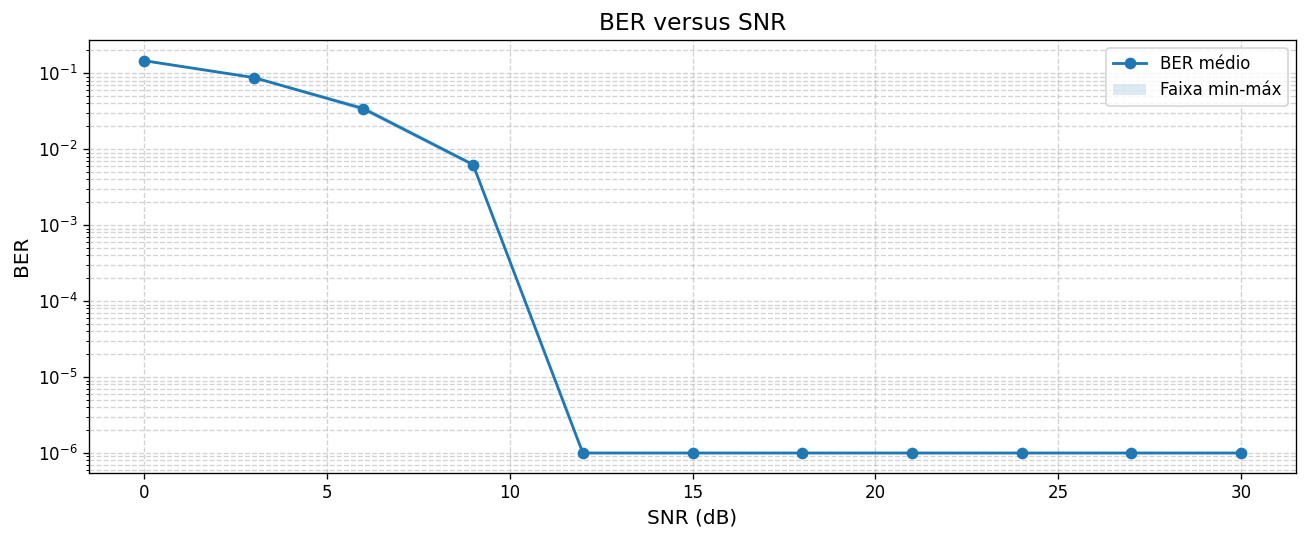

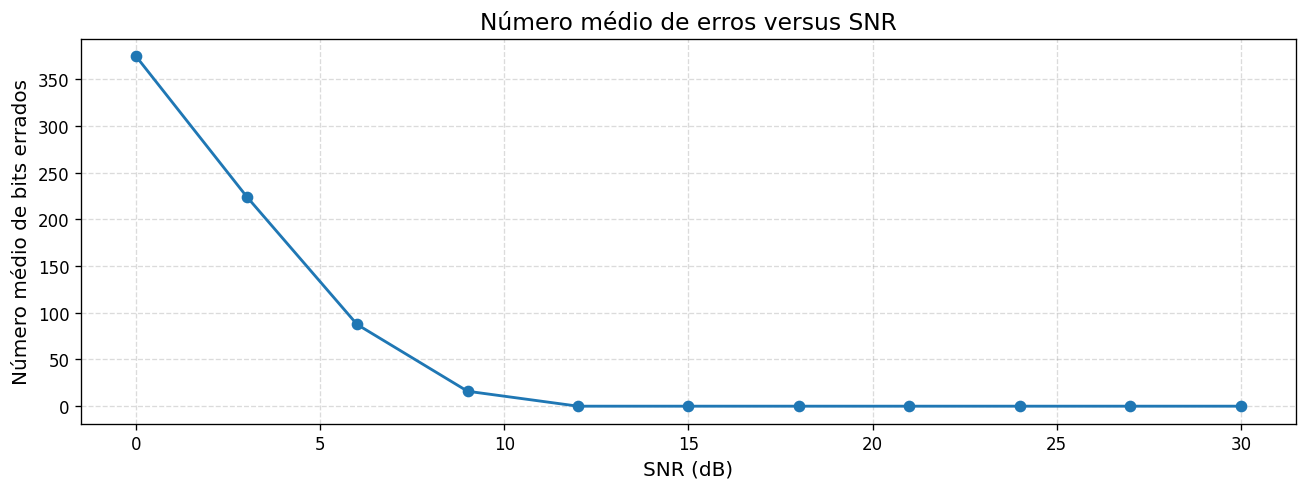

In [17]:
def executar_receptor_para_snr(SNR_teste_dB, seed_ruido_local=1000):
    if USAR_CANAL_SELETIVO:
        rx_canal = canal_seletivo(sinal_tx_awg, Freq_sel_resp)
    else:
        rx_canal = sinal_tx_awg.copy()

    rx_awgn, _, _, _ = canal_awgn(rx_canal, SNR_teste_dB, seed=seed_ruido_local)
    rx_desync = aplicar_dessincronizacao(rx_awgn, DeltaT)

    atraso, _ = sincronizar_por_preambulo(rx_desync, referencia_sync)
    rx_sync = rx_desync[atraso : atraso + len(sinal_tx_K2)]
    if len(rx_sync) < len(sinal_tx_K2):
        rx_sync = np.pad(rx_sync, (0, len(sinal_tx_K2) - len(rx_sync)))

    if USAR_CANAL_SELETIVO and USAR_EQUALIZADOR:
        rx_eq = equalizar_freq_mode_same(rx_sync, Freq_sel_resp, eps=1e-3)
    else:
        rx_eq = rx_sync

    rx_down = downsampling_K2(rx_eq, K2, fase=0)
    sym_frame_rx, _, _, _, _ = filtro_casado_e_amostragem_com_preambulo(
        rx_down,
        pulso,
        K1,
        simbolos_preambulo,
        n_simbolos_total=len(simbolos_frame)
    )

    sym_dados_rx = sym_frame_rx[Nsync : Nsync + len(simbolos_dados)]
    bits_rx_shuf_pad = demapear_simbolos(sym_dados_rx, Mod_format, M)
    bits_rx_shuf = bits_rx_shuf_pad[:len(TextoShuf)]
    bits_rx = deshuffle_bits(bits_rx_shuf, indices_shuffle)[:len(TextoBits)]

    erros = int(np.sum(bits_rx != TextoBits))
    BER = erros / len(TextoBits)
    return BER, erros, atraso


SNR_lista_dB = np.arange(0, 31, 3)
Nrep = 2
BER_medio = []
BER_min = []
BER_max = []
erros_medio = []

for snr in SNR_lista_dB:
    bers = []
    erros_rep = []
    for rep in range(Nrep):
        BER, erros, atraso = executar_receptor_para_snr(snr, seed_ruido_local=3000 + 100*rep + int(snr))
        bers.append(BER)
        erros_rep.append(erros)
    BER_medio.append(np.mean(bers))
    BER_min.append(np.min(bers))
    BER_max.append(np.max(bers))
    erros_medio.append(np.mean(erros_rep))
    print(f'SNR = {snr:>2} dB -> BER médio = {np.mean(bers):.4e}, erros médios = {np.mean(erros_rep):.1f}')

BER_medio = np.array(BER_medio)
BER_min = np.array(BER_min)
BER_max = np.array(BER_max)
erros_medio = np.array(erros_medio)

plt.figure(figsize=(11, 4.6))
plt.semilogy(SNR_lista_dB, np.maximum(BER_medio, 1e-6), 'o-', label='BER médio')
plt.fill_between(SNR_lista_dB, np.maximum(BER_min, 1e-6), np.maximum(BER_max, 1e-6), alpha=0.15, label='Faixa min-máx')
plt.title('BER versus SNR')
plt.xlabel('SNR (dB)')
plt.ylabel('BER')
plt.grid(True, which='both', linestyle='--', alpha=0.55)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 4.2))
plt.plot(SNR_lista_dB, erros_medio, 'o-')
plt.title('Número médio de erros versus SNR')
plt.xlabel('SNR (dB)')
plt.ylabel('Número médio de bits errados')
plt.tight_layout()
plt.show()

## 17. Exportação para o AWG

No final, o sinal transmitido é salvo em um arquivo CSV para uso no gerador de formas de onda.

Para modulações complexas, o arquivo fica com duas colunas: `I` e `Q`. Para modulações reais, a coluna `Q` fica praticamente zerada.

Arquivo exportado: /content/sinal_awg_apresentacao.csv
Formato dos dados exportados: (22160, 2)


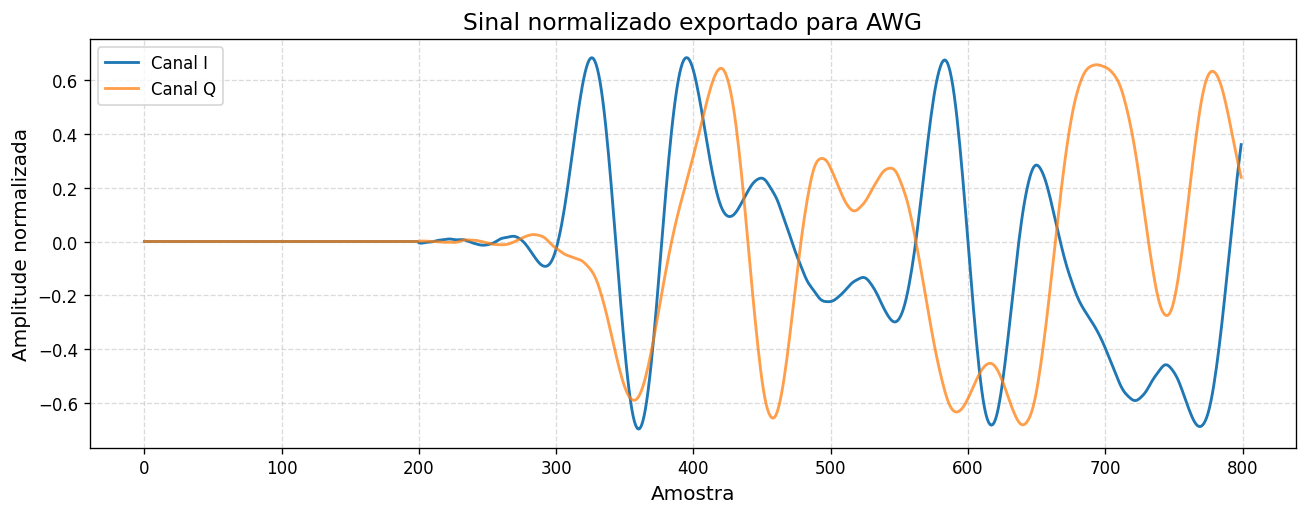

In [18]:
def exportar_awg_csv(sinal, nome_arquivo='sinal_awg_apresentacao.csv', normalizar=True):
    sinal = np.asarray(sinal, dtype=complex)
    if normalizar:
        max_abs = np.max(np.abs(sinal))
        if max_abs > 0:
            sinal = sinal / max_abs
    dados = np.column_stack([np.real(sinal), np.imag(sinal)])
    caminho = Path(nome_arquivo)
    np.savetxt(caminho, dados, delimiter=',', header='I,Q', comments='', fmt='%.10f')
    return caminho, dados

arquivo_awg, dados_awg = exportar_awg_csv(sinal_tx_awg, nome_arquivo='sinal_awg_apresentacao.csv')

print(f'Arquivo exportado: {arquivo_awg.resolve()}')
print(f'Formato dos dados exportados: {dados_awg.shape}')

n_mostrar = min(800, len(dados_awg))
plt.figure(figsize=(11, 4.4))
plt.plot(dados_awg[:n_mostrar, 0], label='Canal I')
plt.plot(dados_awg[:n_mostrar, 1], alpha=0.75, label='Canal Q')
plt.title('Sinal normalizado exportado para AWG')
plt.xlabel('Amostra')
plt.ylabel('Amplitude normalizada')
plt.legend()
plt.tight_layout()
plt.show()